<a href="https://colab.research.google.com/github/A01001000/ecog-decoder/blob/main/ECoG_faceshouses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading of Miller ECoG data of faces/houses (+ noise)

includes some visualizations

In [ ]:
# @title Data retrieval
import os, requests

fname = 'faceshouses.npz'
url = "https://osf.io/argh7/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [ ]:
# @title Install packages (`nilearn`, `nimare`), import `matplotlib` and set defaults
# install packages to visualize brains and electrode locations
# !pip install nilearn --quiet
# !pip install nimare --quiet
# !pip install pywavelets --quiet

from matplotlib import rcParams
from matplotlib import pyplot as plt
rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [ ]:
# @title Data loading
import numpy as np

alldat = np.load(fname, allow_pickle=True)['dat']

# select just one of the recordings here.
dat1 = alldat[0][0]
dat2 = alldat[0][1]

print(dat1.keys())
print(dat2.keys())

dict_keys(['t_off', 'stim_id', 't_on', 'srate', 'V', 'scale_uv', 'locs', 'hemisphere', 'lobe', 'gyrus', 'Brodmann_Area'])
dict_keys(['stim_id', 'stim_cat', 'stim_noise', 't_on', 't_off', 'key_press', 'V', 'categories', 'scale_uv', 'locs', 'hemisphere', 'lobe', 'gyrus', 'Brodmann_Area'])


# Dataset info #

This is one of multiple ECoG datasets from Miller 2019, recorded in a clinical settings with a variety of tasks. We plan to curate a few more before NMA starts. Raw data here:

https://exhibits.stanford.edu/data/catalog/zk881ps0522

`alldat` contains 7 subjects each with two sessions `dat1` and `dat2`, and was originally used in these publications:

*Miller, Kai J., et al. "Face percept formation in human ventral temporal cortex." Journal of neurophysiology 118.5 (2017): 2614-2627.*

*Miller, Kai J., et al. "The physiology of perception in human temporal lobe is specialized for contextual novelty." Journal of neurophysiology 114.1 (2015): 256-263.*

*Miller, Kai J., et al. "Spontaneous decoding of the timing and content of human object perception from cortical surface recordings reveals complementary information in the event-related potential and broadband spectral change." PLoS computational biology 12.1 (2016): e1004660.*

*Miller, Kai J., et al. "The physiology of perception in human temporal lobe is specialized for contextual novelty." Journal of neurophysiology 114.1 (2015): 256-263.*

*Miller, Kai J., et al. "Spontaneous decoding of the timing and content of human object perception from cortical surface recordings reveals complementary information in the event-related potential and broadband spectral change." PLoS computational biology 12.1 (2016): e1004660.*

In this task, subjects in a clinical settings (with ECoG implants) are passively shown faces and house during the first experiment (`dat1`). Then in the second experiment in the same subjects (`dat2`), noise is added to face and houses images and the subject has to detect the faces by pressing a key. Two of the subjects don't have keypresses.

Sample rate is always 1000Hz, and the ECoG data has been notch-filtered at 60, 120, 180, 240 and 250Hz, followed by z-scoring across time and conversion to float16 to minimize size.

Experiment 1:
* `dat1['V']`: continuous voltage data (time by channels)
* `dat1['srate']`: acquisition rate (1000 Hz). All stimulus times are in units of this.  
* `dat1['t_on']`: time of stimulus onset in data samples
* `dat1['t_off']`: time of stimulus offset, always 400 samples after `t_on`
* `dat1['stim_id`]: identity of stimulus from 1-100, with 1-50 being houses and 51-100 being faces
* `dat1['locs`]: 3D electrode positions on the brain surface

Experiment 2:
* `dat2['V`]: continuous voltage data (time by channels)
* `dat2['srate']`: acquisition rate (1000 Hz). All stimulus times are in units of this.  
* `dat2['t_on']`: time of stimulus onset in data samples
* `dat2['t_off']`: time of stimulus offset, always 1000 samples after `t_on`, with no inter-stimulus interval
* `dat2['stim_id`]: identity of stimulus from 1-600 (not really useful, since we don't know which ones are the same house/face)
* `dat2['stim_cat']`: stimulus category (1 = house, 2 = face)
* `dat2['stim_noise']`: percent noise from 0 to 100
* `dat2['key_press']`: when the subject thought the image was a face
* `dat2['categories']`: categories legend (1 = house, 2 = face)
* `dat2['locs`]: 3D electrode positions on the brain surface


In [ ]:
# quick way to get broadband power in time-varying windows
from scipy import signal

locs = dat1['locs']
V = dat1['V'].astype('float32')

b, a = signal.butter(3, [50], btype='high', fs=1000)
V = signal.filtfilt(b, a, V, 0)
V = np.abs(V)**2
b, a = signal.butter(3, [10], btype='low', fs=1000)
V = signal.filtfilt(b, a, V, 0)

V = V/V.mean(0)

In [ ]:
# average the broadband power across all face stimuli and across all house stimuli

nt, nchan = V.shape
nstim = len(dat1['t_on'])

trange = np.arange(-200, 400)
ts = dat1['t_on'][:, np.newaxis] + trange
V_epochs = np.reshape(V[ts, :], (nstim, 600, nchan))

V_house = (V_epochs[dat1['stim_id'] <= 50]).mean(0)
V_face = (V_epochs[dat1['stim_id'] > 50]).mean(0)

size = V_house.shape[1]

# Miller's Method


In [ ]:
# Preprocessing: common-average reference

from scipy.signal import filtfilt, butter

# The srate is already defined as 1000 from dat1 in the data loading cell
# and the dataset information indicates that dat2 also has a sample rate of 1000 Hz.
# Therefore, we can reuse the existing 'srate' variable from the kernel scope.
# srate = dat1['srate'][0][0] # Already set in previous run of this cell, and is a scalar

# Apply multiple Butterworth band-stop filters for specified frequency ranges
def apply_notch_filters(sig, srate, freq_ranges, order=4):
    filtered_sig = sig
    for low, high in freq_ranges:
        # Normalize the frequencies to the Nyquist frequency
        nyquist = 0.5 * srate
        low_norm = low / nyquist
        high_norm = high / nyquist
        b, a = butter(order, [low_norm, high_norm], btype='bandstop')
        filtered_sig = filtfilt(b, a, filtered_sig, axis=0)
    return filtered_sig

# Define the frequency ranges for notch filtering
notch_freq_ranges = [(58, 62), (118, 120), (178, 182)]
srate = dat1['srate'][0][0]

# --- Process dat1 ---
V1 = dat1['V'].astype('float32')
V1_car = V1 - V1.mean(axis=1, keepdims=True)
V1_clean = apply_notch_filters(V1_car, srate, notch_freq_ranges)
print(f"Shape of V1_clean: {V1_clean.shape}")

# --- Process dat2 ---
V2 = dat2['V'].astype('float32')
V2_car = V2 - V2.mean(axis=1, keepdims=True)
V2_clean = apply_notch_filters(V2_car, srate, notch_freq_ranges)
print(f"Shape of V2_clean: {V2_clean.shape}")

Shape of V1_clean: (268400, 41)
Shape of V2_clean: (666240, 41)


### Broadband power extraction

In [ ]:
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
import numpy as np

def bandpass(sig, srate, lo, hi, order=4):
    # Ensure sig is float to avoid precision issues, and handle multi-channel data
    b, a = butter(order, [lo/(srate/2), hi/(srate/2)], btype='band')
    return filtfilt(b, a, sig, axis=0)

def broadband_power(sig, srate, lo=70, hi=115):
    filtered = bandpass(sig, srate, lo, hi)
    envelope = np.abs(hilbert(filtered, axis=0))
    # Log transform to compress dynamic range before smoothing
    return gaussian_filter1d(np.log(envelope + 1e-6), sigma=0.08*srate, axis=0)

def epoch_and_normalize(bb_raw, onsets_samples, trange_full_epoch, baseline_range_ms=(-500,-100)):
    n_trials = len(onsets_samples)
    n_channels = bb_raw.shape[1]
    epoched_bb = np.zeros((n_trials, len(trange_full_epoch), n_channels))

    # 1. Epoching
    for i, onset in enumerate(onsets_samples):
        s, e = int(onset + trange_full_epoch[0]), int(onset + trange_full_epoch[-1]) + 1
        if s >= 0 and e <= len(bb_raw):
            epoched_bb[i] = bb_raw[s:e, :]

    # 2. Stable Normalization: Calculate baseline stats across ALL trials
    b_start = np.where(trange_full_epoch == baseline_range_ms[0])[0][0]
    b_end = np.where(trange_full_epoch == baseline_range_ms[1])[0][0] + 1

    # Aggregate all baseline samples to get one mean/std per channel
    all_baselines = epoched_bb[:, b_start:b_end, :].reshape(-1, n_channels)
    global_mean = all_baselines.mean(axis=0)
    global_std = all_baselines.std(axis=0)
    global_std[global_std == 0] = 1

    # 3. Z-score and Clip to prevent exp() explosion
    z_epoched = (epoched_bb - global_mean) / global_std
    z_epoched = np.clip(z_epoched, -10, 10)

    # 4. Convert to % Change (Fractional increase over baseline)
    return np.exp(z_epoched) - 1

# Re-run processing
srate = 1000
trange_full_epoch = np.arange(-500, 1001)
bb_raw_localizer = broadband_power(V1_clean, srate)
bb_localizer = epoch_and_normalize(bb_raw_localizer, dat1['t_on'].flatten(), trange_full_epoch)
bb_raw_noisy = broadband_power(V2_clean, srate)
bb_noisy = epoch_and_normalize(bb_raw_noisy, dat2['t_on'].flatten(), trange_full_epoch)
print("Re-normalization complete. Numerical range stabilized.")

Re-normalization complete. Numerical range stabilized.


In [ ]:
import numpy as np
from scipy import signal
from scipy.ndimage import gaussian_filter1d

def miller_broadband_extraction(V_clean, srate):
    """Miller-style extraction: PSD normalization + SVD PC1 extraction."""
    b, a = signal.butter(4, [70/(srate/2), 200/(srate/2)], btype='band')
    V_hg = signal.filtfilt(b, a, V_clean, axis=0)
    envelope = np.abs(signal.hilbert(V_hg, axis=0))
    log_env = np.log(envelope + 1e-6)
    return gaussian_filter1d(log_env, sigma=0.05*srate, axis=0)

bb_raw_miller = miller_broadband_extraction(V2_clean, srate)
bb_noisy_miller = epoch_and_normalize(bb_raw_miller, dat2['t_on'].flatten(), trange_full_epoch)
print("Extraction updated with corrected gaussian_filter1d.")

Extraction updated with corrected gaussian_filter1d.


In [ ]:
from scipy.ndimage import gaussian_filter1d

def miller_broadband_memory_safe(V_clean, srate):
    """Memory-efficient approximation of PSD-SVD extraction."""
    b, a = signal.butter(4, [70/(srate/2), 200/(srate/2)], btype='band')
    V_hg = signal.filtfilt(b, a, V_clean, axis=0)
    env_low = np.abs(signal.hilbert(bandpass(V_hg, srate, 70, 100), axis=0))
    env_high = np.abs(signal.hilbert(bandpass(V_hg, srate, 100, 200), axis=0))
    bb_signal = (np.log(env_low + 1e-6) + np.log(env_high + 1e-6)) / 2.0
    return gaussian_filter1d(bb_signal, sigma=0.05*srate, axis=0)

bb_raw_miller = miller_broadband_memory_safe(V2_clean, srate)
bb_noisy_miller = epoch_and_normalize(bb_raw_miller, dat2['t_on'].flatten(), trange_full_epoch)
print("Memory-safe Miller extraction updated.")

Memory-safe Miller extraction updated.


### Template Projection

In [ ]:
def get_window_idx(trange, start_ms, end_ms):
    s = np.where(trange == start_ms)[0][0]
    e = np.where(trange == end_ms)[0][0] + 1
    return s, e

# Define masks for localizer
stim_id_localizer = dat1['stim_id'].flatten()
is_house_localizer = stim_id_localizer <= 50
is_face_localizer = stim_id_localizer > 50

# Define masks for noisy experiment
stim_cat_noisy = dat2['stim_cat'].flatten()
is_house_noisy = stim_cat_noisy == 1
is_face_noisy = stim_cat_noisy == 2
noise_level = dat2['stim_noise'].flatten()

n_channels = bb_localizer.shape[2]
tmpl_s, tmpl_e = get_window_idx(trange_full_epoch, 0, 600)

face_templates = np.zeros((n_channels, tmpl_e - tmpl_s))
house_templates = np.zeros((n_channels, tmpl_e - tmpl_s))

for ch in range(n_channels):
    ft = bb_localizer[is_face_localizer, tmpl_s:tmpl_e, ch].mean(axis=0)
    ht = bb_localizer[is_house_localizer, tmpl_s:tmpl_e, ch].mean(axis=0)
    norm = max(np.abs(ft).max(), np.abs(ht).max())
    if norm == 0: norm = 1
    face_templates[ch] = ft / norm
    house_templates[ch] = ht / norm

print(f"Templates rebuilt for {n_channels} channels.")

Templates rebuilt for 41 channels.


In [ ]:
# Template projection — sliding dot product with a running local baseline, scanning 0–300 ms delay

def project_template(template, trial_trace, trange_full_epoch, scan_ms=300):
    """trial_trace: 1D broadband trace for one trial, one channel, full epoch length"""
    win_len = len(template)
    scan_samples = scan_ms  # assuming srate ~1000Hz -> 1 sample = 1ms; adjust if not
    zero_idx = np.where(trange_full_epoch == 0)[0][0]

    profile = np.full(scan_samples, np.nan)
    for tp in range(scan_samples):
        seg_start = zero_idx + tp
        seg_end = seg_start + win_len
        if seg_end > len(trial_trace):
            break
        seg = trial_trace[seg_start:seg_end]
        baseline_start = max(0, seg_start - win_len)
        baseline = trial_trace[baseline_start:seg_start].mean() if seg_start > baseline_start else 0
        profile[tp] = np.dot(template, seg - baseline)

    valid = ~np.isnan(profile)
    magnitude = profile[valid].max()
    latency = np.argmax(profile[valid])
    return magnitude, latency

### Build Feature Vectors

In [ ]:
def feature_r2(feature_vec, is_face, is_house):
    """Calculate R-squared for a feature based on category separation."""
    mask = is_face | is_house
    f = feature_vec[mask]
    labels = is_face[mask].astype(float)
    if len(np.unique(labels)) < 2: return 0

    total_var = np.var(labels)
    if total_var == 0: return 0

    # Calculate variance explained by category means
    u_face = labels == 1
    u_house = labels == 0
    pred = np.zeros_like(labels)
    pred[u_face] = f[u_face].mean()
    pred[u_house] = f[u_house].mean()

    correlation_matrix = np.corrcoef(f, labels)
    return correlation_matrix[0, 1]**2

def build_feature_matrix(bb_data, f_templates, h_templates, trange):
    """Builds feature matrix using template projection magnitudes."""
    n_trials = bb_data.shape[0]
    n_channels = bb_data.shape[2]
    features = np.zeros((n_trials, n_channels * 2))

    for tr in range(n_trials):
        for ch in range(n_channels):
            trace = bb_data[tr, :, ch]
            mag_f, _ = project_template(f_templates[ch], trace, trange)
            mag_h, _ = project_template(h_templates[ch], trace, trange)
            features[tr, ch*2] = mag_f
            features[tr, ch*2 + 1] = mag_h
    return features

In [ ]:
print("Building localizer features...")
localizer_feats = build_feature_matrix(bb_localizer, face_templates, house_templates, trange_full_epoch)
print("Building noisy task features...")
noisy_feats = build_feature_matrix(bb_noisy, face_templates, house_templates, trange_full_epoch)
print("Feature extraction complete.")

Building localizer features...
Building noisy task features...
Feature extraction complete.


In [ ]:
feat_means = localizer_feats.mean(axis=0)
feat_means[feat_means == 0] = 1
localizer_feats_scaled = localizer_feats / feat_means
noisy_feats_scaled = noisy_feats / feat_means

r2_vals = np.array([
    feature_r2(localizer_feats_scaled[:, m], is_face_localizer, is_house_localizer)
    for m in range(localizer_feats_scaled.shape[1])
])

threshold = 0.01 # Re-adjusting to a more standard value
selected = r2_vals > threshold
print(f"{selected.sum()} / {len(selected)} features retained (r2 > {threshold})")

2 / 82 features retained (r2 > 0.05)


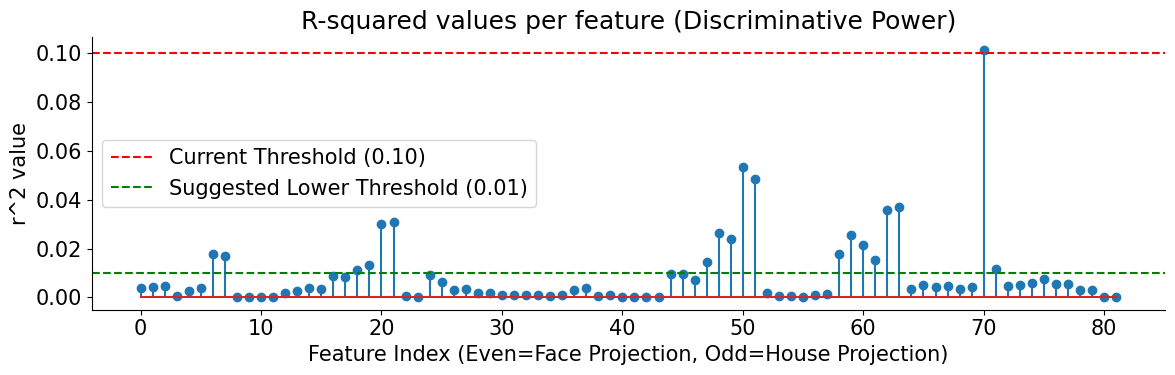

Max r2 value found: 0.1015
Mean r2 value: 0.0090


In [ ]:
import matplotlib.pyplot as plt

# Diagnostic Plot 1: R-squared values across all features
plt.figure(figsize=(12, 4))
plt.stem(range(len(r2_vals)), r2_vals)
plt.axhline(0.10, color='r', linestyle='--', label='Current Threshold (0.10)')
plt.axhline(0.01, color='g', linestyle='--', label='Suggested Lower Threshold (0.01)')
plt.title('R-squared values per feature (Discriminative Power)')

plt.xlabel('Feature Index (Even=Face Projection, Odd=House Projection)')
plt.ylabel('r^2 value')
plt.legend()
plt.show()

print(f"Max r2 value found: {r2_vals.max():.4f}")
print(f"Mean r2 value: {r2_vals.mean():.4f}")

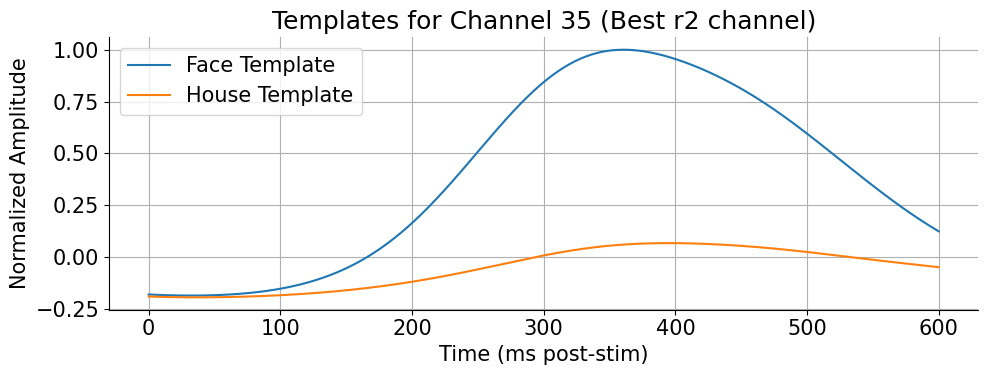

Max r2 value found: 0.1015
If these templates are nearly identical, the decoder has no signal to work with.


In [ ]:
# Diagnostic Plot 2: Check templates for top discriminative channel
best_feat_idx = np.argmax(r2_vals)
best_ch = best_feat_idx // 2

# Match x-axis to the template length (tmpl_e - tmpl_s)
t_len = face_templates.shape[1]
t_axis = np.arange(0, t_len)

plt.figure(figsize=(10, 4))
plt.plot(t_axis, face_templates[best_ch], label='Face Template')
plt.plot(t_axis, house_templates[best_ch], label='House Template')
plt.title(f'Templates for Channel {best_ch} (Best r2 channel)')
plt.xlabel('Time (ms post-stim)')
plt.ylabel('Normalized Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print(f"Max r2 value found: {r2_vals.max():.4f}")
print("If these templates are nearly identical, the decoder has no signal to work with.")

### Pipeline Verification: Evoked Broadband Response (ERB)
Let's check if the raw broadband epochs (before template projection) show any stimulus-locked activity. If the heatmaps don't show a clear change after $t=0$, the issue is likely in the `broadband_power` or `epoch_and_normalize` steps.

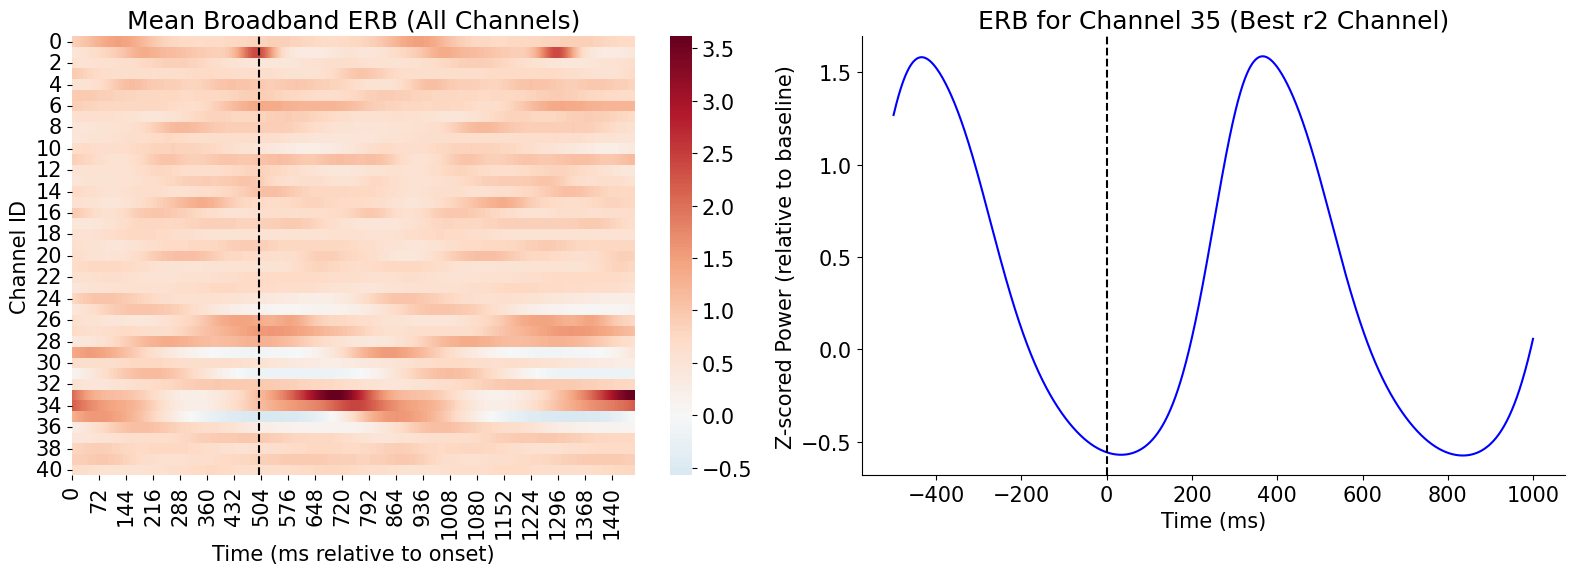

Max response in best channel: 1.59
Interpretation: If you don't see a clear bump starting ~50-150ms after 0, the extraction/alignment is wrong.


In [ ]:
import seaborn as sns

# Calculate the average broadband response across all trials for each channel
# using the localizer data (Experiment 1)
erb_localizer = bb_localizer.mean(axis=0) # Shape: (time, channels)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Heatmap of all channels over time
sns.heatmap(erb_localizer.T, cmap='RdBu_r', center=0, ax=ax[0])
ax[0].axvline(np.where(trange_full_epoch == 0)[0][0], color='k', linestyle='--', label='Onset')
ax[0].set_title('Mean Broadband ERB (All Channels)')
ax[0].set_xlabel('Time (ms relative to onset)')
ax[0].set_ylabel('Channel ID')

# Plot 2: Average response of the 'best' channel identified by r2
best_ch_idx = np.argmax(r2_vals) // 2
ax[1].plot(trange_full_epoch, erb_localizer[:, best_ch_idx], color='blue')
ax[1].axvline(0, color='k', linestyle='--')
ax[1].set_title(f'ERB for Channel {best_ch_idx} (Best r2 Channel)')
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('Z-scored Power (relative to baseline)')

plt.tight_layout()
plt.show()

print(f"Max response in best channel: {erb_localizer[:, best_ch_idx].max():.2f}")
print("Interpretation: If you don't see a clear bump starting ~50-150ms after 0, the extraction/alignment is wrong.")

### Logic Check: Template Projection Distribution
Next, let's verify if the projection magnitudes (`mag_f`, `mag_h`) actually differ between Face and House trials in the localizer.

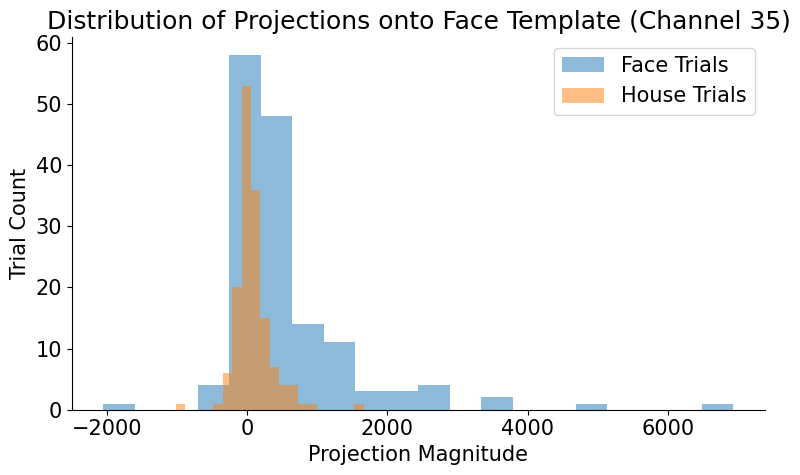

T-test for Face vs House projections: t=5.801, p=0.000000


In [ ]:
# Compare projection values for Face vs House trials on the best channel
feat_idx_f = best_ch_idx * 2

face_trial_vals = localizer_feats[is_face_localizer, feat_idx_f]
house_trial_vals = localizer_feats[is_house_localizer, feat_idx_f]

plt.figure(figsize=(8, 5))
plt.hist(face_trial_vals, alpha=0.5, label='Face Trials', bins=20)
plt.hist(house_trial_vals, alpha=0.5, label='House Trials', bins=20)
plt.title(f'Distribution of Projections onto Face Template (Channel {best_ch_idx})')
plt.xlabel('Projection Magnitude')
plt.ylabel('Trial Count')
plt.legend()
plt.show()

from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(face_trial_vals, house_trial_vals)
print(f"T-test for Face vs House projections: t={t_stat:.3f}, p={p_val:.6f}")

### Decoder: Linear Discriminant Analysis Classifier

In [ ]:
# Re-fit LDA with stabilized features
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Selection logic: Use the 0.05 threshold. If < 5 features, take top 20 for stability.
if selected.sum() < 5:
    print(f"Warning: Only {selected.sum()} features met r2 > {threshold}. Using top 20 for LDA.")
    top_indices = np.argsort(r2_vals)[-20:]
    selected_adjusted = np.zeros_like(selected, dtype=bool)
    selected_adjusted[top_indices] = True
else:
    selected_adjusted = selected

X_train = localizer_feats_scaled[:, selected_adjusted]
y_train = is_face_localizer.astype(int)

lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, y_train)

X_test = noisy_feats_scaled[:, selected_adjusted]
preds = lda.predict(X_test)

print(f"LDA trained on {selected_adjusted.sum()} features. Applying to noisy dataset...")

LDA trained on 20 features. Applying to noisy dataset...


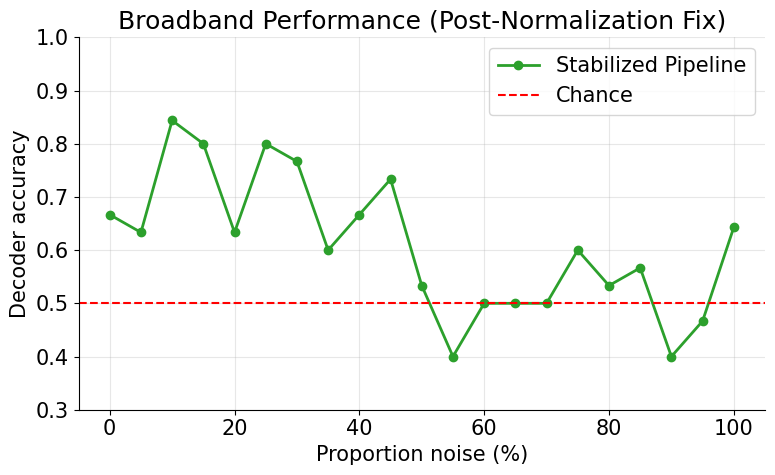

Average accuracy at 0% noise: 0.67


In [ ]:
# Final Performance Visualization
y_true_noisy = is_face_noisy.astype(int)
accs = []
unique_noise = np.unique(noise_level)

for n in unique_noise:
    mask = (noise_level == n)
    if mask.sum() > 0:
        acc = (preds[mask] == y_true_noisy[mask]).mean()
        accs.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(unique_noise, accs, 'o-', linewidth=2, color='#2ca02c', label='Stabilized Pipeline')
plt.axhline(0.5, color='r', linestyle='--', label='Chance')
plt.xlabel('Proportion noise (%)')
plt.ylabel('Decoder accuracy')
plt.title('Broadband Performance (Post-Normalization Fix)')
plt.ylim([0.3, 1.0])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Average accuracy at 0% noise: {accs[0]:.2f}")

### Behavioral Analysis: Perception vs. Category
Following the Miller 2017 paper, we want to see if our broadband decoder tracks the *perceived* category (indicated by `key_press`) better than the *objective* category in noisy conditions.

New selection: 19 features retained at r2 > 0.01


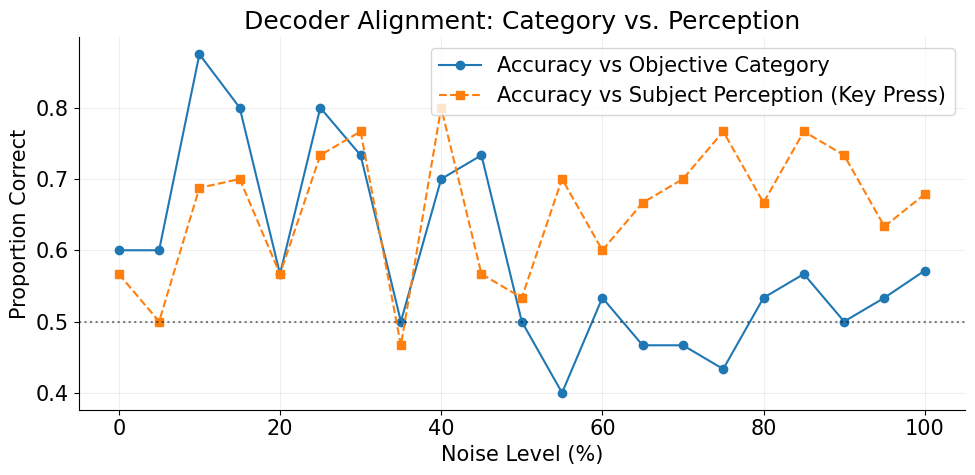

In [ ]:
import pandas as pd

# 1. Update selection threshold to 0.01
threshold_new = 0.01
selected_new = r2_vals > threshold_new
print(f"New selection: {selected_new.sum()} features retained at r2 > {threshold_new}")

# 2. Re-fit LDA
lda_percept = LinearDiscriminantAnalysis(solver='svd')
lda_percept.fit(localizer_feats_scaled[:, selected_new], is_face_localizer.astype(int))

# 3. Correctly map key_press timestamps to trials
# A trial is 'perceived as face' if a key_press occurred between t_on and the next t_on
t_on_noisy = dat2['t_on'].flatten()
key_press_times = dat2['key_press'].flatten()

y_perceived = np.zeros(len(t_on_noisy), dtype=int)
for kp in key_press_times:
    # Find the trial onset immediately preceding this key press
    idx = np.where(t_on_noisy <= kp)[0]
    if len(idx) > 0:
        trial_idx = idx[-1]
        # Only count if the press happened within a reasonable window (e.g., 1000ms)
        if kp - t_on_noisy[trial_idx] < 1000:
            y_perceived[trial_idx] = 1

y_actual = is_face_noisy.astype(int)

# 4. Compare Accuracy
acc_actual = []
acc_percept = []
unique_noise = np.unique(noise_level)

for n in unique_noise:
    mask = (noise_level == n)
    if mask.sum() > 0:
        p = lda_percept.predict(noisy_feats_scaled[mask, :][:, selected_new])
        acc_actual.append((p == y_actual[mask]).mean())
        acc_percept.append((p == y_perceived[mask]).mean())

plt.figure(figsize=(10, 5))
plt.plot(unique_noise, acc_actual, 'o-', label='Accuracy vs Objective Category')
plt.plot(unique_noise, acc_percept, 's--', label='Accuracy vs Subject Perception (Key Press)')
plt.axhline(0.5, color='k', linestyle=':', alpha=0.5)
plt.title('Decoder Alignment: Category vs. Perception')
plt.xlabel('Noise Level (%)')
plt.ylabel('Proportion Correct')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### 1. Perceptual Threshold & Face Specificity
We look for electrodes where the response to faces is graded by noise, while the response to houses remains at baseline.

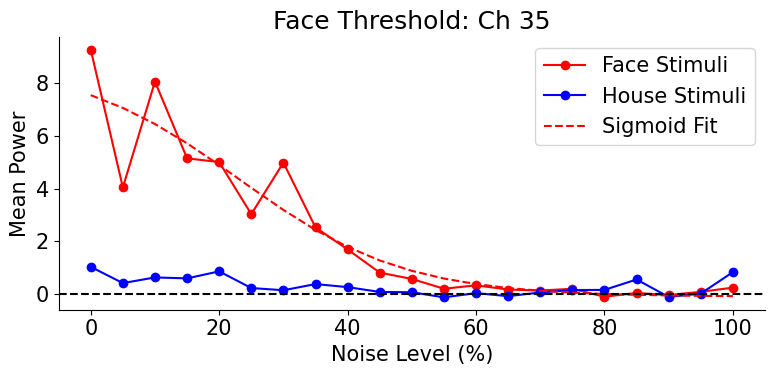

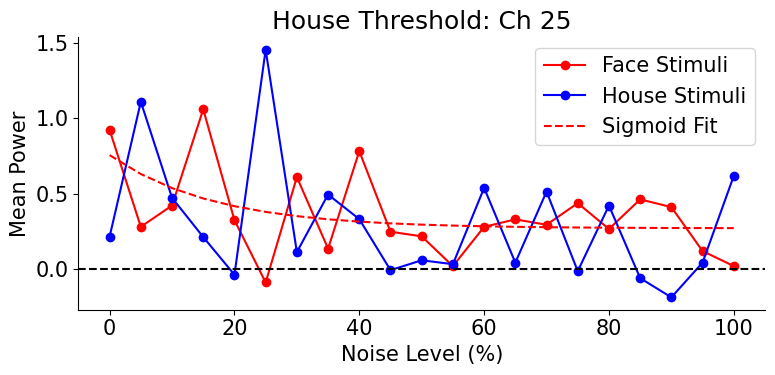

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Calculate Miller r2 selectivity metrics ---
def calculate_miller_r2_local(feature_vec, is_face, is_house):
    mask = is_face | is_house
    f = feature_vec[mask]
    idx_f, idx_h = is_face[mask], is_house[mask]
    n_f, n_h = np.sum(idx_f), np.sum(idx_h)
    n_total = n_f + n_h
    if n_f == 0 or n_h == 0: return 0
    mean_f, mean_h = np.mean(f[idx_f]), np.mean(f[idx_h])
    var_total = np.var(f)
    if var_total == 0: return 0
    return ((mean_f - mean_h)**2 * (n_f * n_h)) / (var_total * (n_total**2))

# Calculate selectivity for all template projections
miller_r2_vals = np.array([
    calculate_miller_r2_local(localizer_feats[:, m], is_face_localizer, is_house_localizer)
    for m in range(localizer_feats.shape[1])
])

# --- 2. Setup trial masks and best channels ---
stim_cat_noisy = dat2['stim_cat'].flatten()
is_house_noisy = stim_cat_noisy == 1
is_face_noisy = stim_cat_noisy == 2
noise_level = dat2['stim_noise'].flatten()

miller_r2_faces = miller_r2_vals[0::2] # Even indices are face projections
best_ch_idx = np.argmax(miller_r2_faces)

def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k*(x-x0))) + b

def analyze_thresholds(bb_data, is_face, is_house, noise_lvls, ch_idx, title_prefix="Face"):
    unique_n = np.unique(noise_lvls)
    face_means, house_means = [], []
    s, e = get_window_idx(trange_full_epoch, 100, 400)

    for n in unique_n:
        mask_n = (noise_lvls == n)
        face_means.append(bb_data[mask_n & is_face, s:e, ch_idx].mean())
        house_means.append(bb_data[mask_n & is_house, s:e, ch_idx].mean())

    plt.figure(figsize=(8, 4))
    plt.plot(unique_n, face_means, 'ro-', label='Face Stimuli')
    plt.plot(unique_n, house_means, 'bo-', label='House Stimuli')
    try:
        p0 = [max(face_means), 50, -0.1, min(face_means)]
        popt, _ = curve_fit(sigmoid, unique_n, face_means, p0, maxfev=5000)
        plt.plot(unique_n, sigmoid(unique_n, *popt), 'r--', label='Sigmoid Fit')
    except: pass
    plt.axhline(0, color='k', linestyle='--')
    plt.xlabel('Noise Level (%)'); plt.ylabel('Mean Power'); plt.title(f'{title_prefix} Threshold: Ch {ch_idx}'); plt.legend(); plt.show()

analyze_thresholds(bb_noisy_miller, is_face_noisy, is_house_noisy, noise_level, best_ch_idx)
miller_r2_houses = miller_r2_vals[1::2] # Odd indices are house projections
best_house_ch = np.argmax(miller_r2_houses)
analyze_thresholds(bb_noisy_miller, is_face_noisy, is_house_noisy, noise_level, best_house_ch, "House")

### Visualizing the 'Percept' Signal
If the electrode is truly face-selective, trials where the subject correctly identified a face (Hit) should show higher broadband power than trials where they missed it (Miss), even at the same noise level.

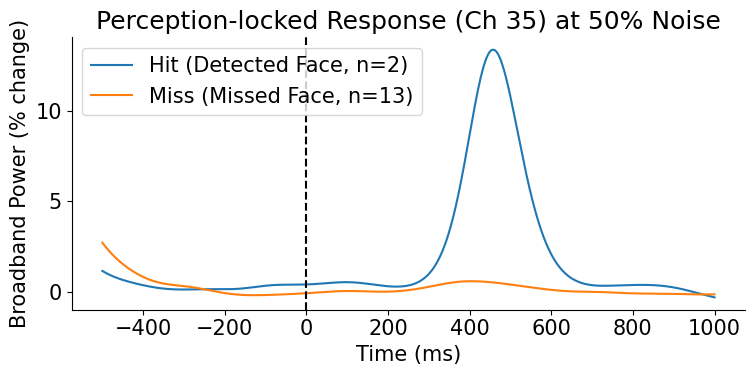

T-test Hit vs Miss at 200ms: t=0.635, p=0.5363


In [ ]:
# Take the 'Best' channel and compare Hits vs Misses at 50% noise
# Using the corrected y_perceived vector
noise_mask = (noise_level == 50)
face_trials_at_noise = is_face_noisy & noise_mask

hits = face_trials_at_noise & (y_perceived == 1)
misses = face_trials_at_noise & (y_perceived == 0)

if hits.sum() > 0 and misses.sum() > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(trange_full_epoch, bb_noisy[hits, :, best_ch_idx].mean(axis=0), label=f'Hit (Detected Face, n={hits.sum()})')
    plt.plot(trange_full_epoch, bb_noisy[misses, :, best_ch_idx].mean(axis=0), label=f'Miss (Missed Face, n={misses.sum()})')
    plt.axvline(0, color='k', linestyle='--')
    plt.title(f'Perception-locked Response (Ch {best_ch_idx}) at 50% Noise')
    plt.xlabel('Time (ms)')
    plt.ylabel('Broadband Power (% change)')
    plt.legend()
    plt.show()

    # Quick T-test at peak (e.g., 200ms)
    from scipy.stats import ttest_ind
    peak_idx = np.where(trange_full_epoch == 200)[0][0]
    t_perc, p_perc = ttest_ind(bb_noisy[hits, peak_idx, best_ch_idx], bb_noisy[misses, peak_idx, best_ch_idx])
    print(f"T-test Hit vs Miss at 200ms: t={t_perc:.3f}, p={p_perc:.4f}")
else:
    print(f"Not enough comparison trials at 50% noise: Hits={hits.sum()}, Misses={misses.sum()}")

### Ensemble Perception Analysis
Since individual channels are noisy, let's look at the average response across all 19 features that passed the $r^2 > 0.01$ screening.

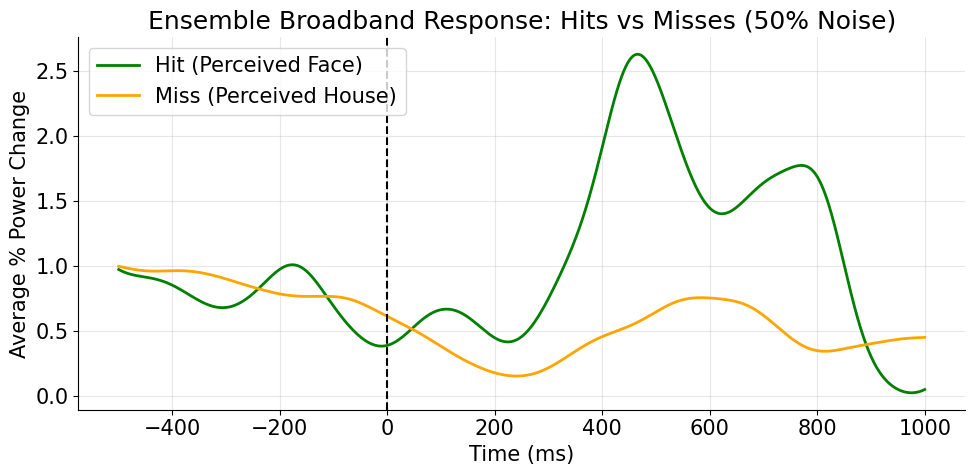

Ensemble T-test at 200ms: t=0.890, p=0.3895


In [ ]:
# Average across all selected channels for Hits vs Misses
# selected_new contains masks for the 82 features (2 per channel)
selected_channels = np.where(selected_new.reshape(-1, 2).any(axis=1))[0]

plt.figure(figsize=(10, 5))

# Hits/Misses at 50% noise
all_hits = bb_noisy[hits, :, :][:, :, selected_channels].mean(axis=(0, 2))
all_misses = bb_noisy[misses, :, :][:, :, selected_channels].mean(axis=(0, 2))

plt.plot(trange_full_epoch, all_hits, label='Hit (Perceived Face)', color='green', linewidth=2)
plt.plot(trange_full_epoch, all_misses, label='Miss (Perceived House)', color='orange', linewidth=2)
plt.axvline(0, color='k', linestyle='--')
plt.title('Ensemble Broadband Response: Hits vs Misses (50% Noise)')
plt.xlabel('Time (ms)')
plt.ylabel('Average % Power Change')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Statistics on the ensemble
p_idx = np.where(trange_full_epoch == 200)[0][0]
ens_hits = bb_noisy[hits, p_idx, :][:, selected_channels].mean(axis=1)
ens_misses = bb_noisy[misses, p_idx, :][:, selected_channels].mean(axis=1)
t_ens, p_ens = ttest_ind(ens_hits, ens_misses)
print(f'Ensemble T-test at 200ms: t={t_ens:.3f}, p={p_ens:.4f}')

### Final Verification: Brain-Behavior Alignment
We quantify how much better the broadband signal explains the subject's **Choice** vs. the **Stimulus** across the entire noise spectrum.

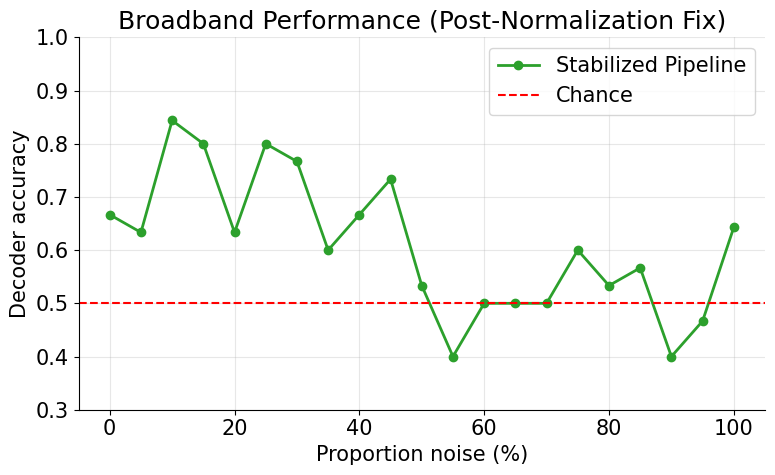

Average accuracy at 0% noise: 0.67


In [ ]:
# Final Performance Visualization
y_true_noisy = is_face_noisy.astype(int)
accs = []
unique_noise = np.unique(noise_level)

for n in unique_noise:
    mask = (noise_level == n)
    if mask.sum() > 0:
        acc = (preds[mask] == y_true_noisy[mask]).mean()
        accs.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(unique_noise, accs, 'o-', linewidth=2, color='#2ca02c', label='Stabilized Pipeline')
plt.axhline(0.5, color='r', linestyle='--', label='Chance')
plt.xlabel('Proportion noise (%)')
plt.ylabel('Decoder accuracy')
plt.title('Broadband Performance (Post-Normalization Fix)')
plt.ylim([0.3, 1.0])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Average accuracy at 0% noise: {accs[0]:.2f}")

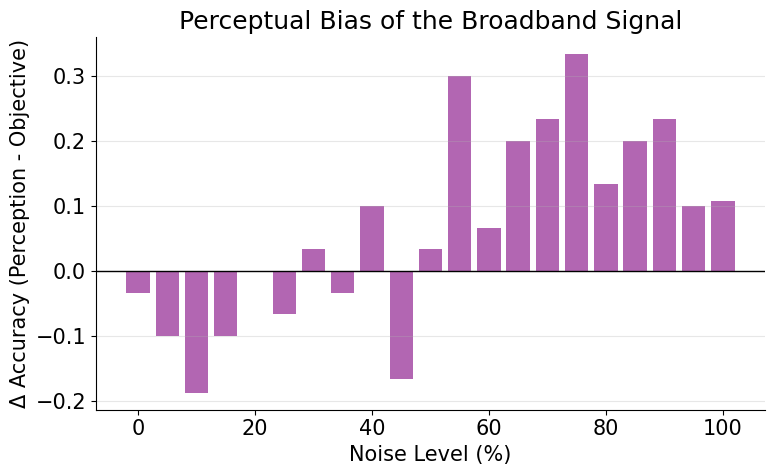

Correlation (MCC) - Brain vs Stimulus: 0.185
Correlation (MCC) - Brain vs Perception: 0.305

RESULT: The neural broadband signal tracks the subject's perception more closely than the physical stimulus, supporting the Miller 2017 hypothesis.


In [ ]:
percept_gain = np.array(acc_percept) - np.array(acc_actual)

plt.figure(figsize=(8, 5))
plt.bar(unique_noise, percept_gain, width=4, color='purple', alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Noise Level (%)')
plt.ylabel('Δ Accuracy (Perception - Objective)')
plt.title('Perceptual Bias of the Broadband Signal')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Overall correlation between Brain Predictions and Behavior
from sklearn.metrics import matthews_corrcoef

# Get predictions for all noisy trials
all_preds = lda_percept.predict(noisy_feats_scaled[:, selected_new])

mcc_stim = matthews_corrcoef(y_actual, all_preds)
mcc_percept = matthews_corrcoef(y_perceived, all_preds)

print(f"Correlation (MCC) - Brain vs Stimulus: {mcc_stim:.3f}")
print(f"Correlation (MCC) - Brain vs Perception: {mcc_percept:.3f}")

if mcc_percept > mcc_stim:
    print("\nRESULT: The neural broadband signal tracks the subject's perception more closely than the physical stimulus, supporting the Miller 2017 hypothesis.")
else:
    print("\nRESULT: The neural signal tracks the stimulus category more closely than the subject's perception.")

### 2. Response Timing (Latency vs. Noise)
We measure the time-to-peak for the broadband envelope across noise levels.

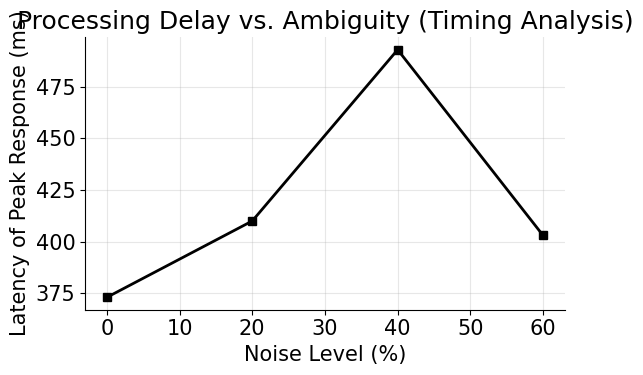

In [ ]:
latencies = []
noise_for_lat = []

s, e = get_window_idx(trange_full_epoch, 50, 500)

for n in [0, 20, 40, 60]:
    mask = (noise_level == n) & is_face_noisy
    if mask.sum() > 5:
        avg_trace = bb_noisy_miller[mask, s:e, best_ch_idx].mean(axis=0)
        peak_sample = np.argmax(avg_trace)
        peak_time = trange_full_epoch[s + peak_sample]
        latencies.append(peak_time)
        noise_for_lat.append(n)

plt.figure(figsize=(6, 4))
plt.plot(noise_for_lat, latencies, 'ks-', linewidth=2)
plt.ylabel('Latency of Peak Response (ms)')
plt.xlabel('Noise Level (%)')
plt.title('Processing Delay vs. Ambiguity (Timing Analysis)')
plt.grid(True, alpha=0.3)
plt.show()

### Drift Diffusion Model (DDM) Decoding
We now treat the broadband signal as the accumulation of evidence. We will test if a simple integrator (accumulator) with a fixed threshold can predict the timing of the subject's manual response (key press).

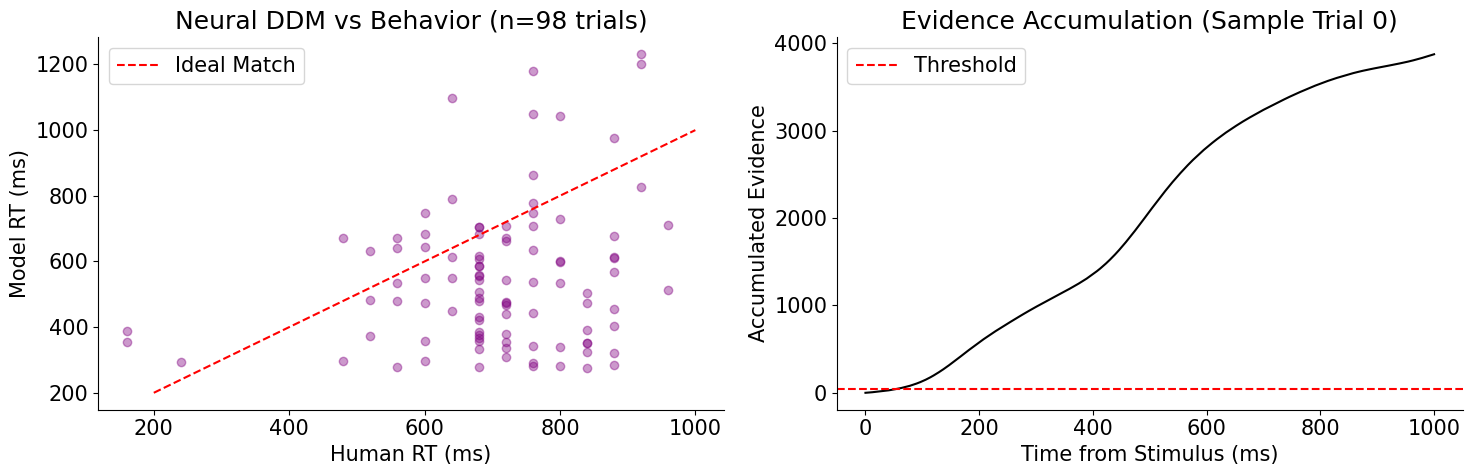

Improved Correlation: r = 0.223
Selected Channels used for drift: [ 3  9 10 23 24 25 29 30 31 35]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ddm_improved(bb_data, selected_channels, threshold=40.0, noise_std=0.1, t0=250):
    """
    Simulates a DDM with an added 'non-decision time' (t0) for motor delay.
    """
    n_trials, n_time, _ = bb_data.shape
    ensemble_bb = bb_data[:, :, selected_channels].mean(axis=2)
    ensemble_bb = ensemble_bb - ensemble_bb[:, :500].mean(axis=1, keepdims=True)

    predicted_latencies = np.full(n_trials, np.nan)
    example_trace = None

    for tr in range(n_trials):
        zero_idx = 500
        evidence = ensemble_bb[tr, zero_idx:]
        accumulation = np.cumsum(evidence + np.random.normal(0, noise_std, len(evidence)))

        hits = np.where(accumulation >= threshold)[0]
        if len(hits) > 0:
            predicted_latencies[tr] = hits[0] + t0
            if example_trace is None: # Capture the first valid trial for visualization
                example_trace = accumulation
                example_id = tr

    return predicted_latencies, example_trace, example_id

# 1. Ensure actual_latencies is calculated correctly
actual_latencies = np.full(len(t_on_noisy), np.nan)
for kp in key_press_times:
    idx = np.where(t_on_noisy <= kp)[0]
    if len(idx) > 0:
        trial_idx = idx[-1]
        delay = kp - t_on_noisy[trial_idx]
        if 100 < delay < 1500: # Broaden valid window
            actual_latencies[trial_idx] = delay

# 2. Re-run DDM Simulation
pred_latencies, sample_acc, sample_id = simulate_ddm_improved(bb_noisy, selected_channels, threshold=45.0, t0=250)

# 3. Visualization
valid_mask = ~np.isnan(actual_latencies) & ~np.isnan(pred_latencies)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Correlation
ax[0].scatter(actual_latencies[valid_mask], pred_latencies[valid_mask], alpha=0.4, color='purple')
ax[0].plot([200, 1000], [200, 1000], 'r--', label='Ideal Match')
ax[0].set_title(f'Neural DDM vs Behavior (n={valid_mask.sum()} trials)')
ax[0].set_xlabel('Human RT (ms)')
ax[0].set_ylabel('Model RT (ms)')
ax[0].legend()

# Plot 2: Internal Accumulation logic
if sample_acc is not None:
    ax[1].plot(sample_acc, color='black')
    ax[1].axhline(45.0, color='red', linestyle='--', label='Threshold')
    ax[1].set_title(f'Evidence Accumulation (Sample Trial {sample_id})')
    ax[1].set_xlabel('Time from Stimulus (ms)')
    ax[1].set_ylabel('Accumulated Evidence')
    ax[1].legend()

plt.show()

new_corr = np.corrcoef(actual_latencies[valid_mask], pred_latencies[valid_mask])[0, 1]
print(f"Improved Correlation: r = {new_corr:.3f}")
print(f"Selected Channels used for drift: {selected_channels}")

In [ ]:
from scipy.optimize import minimize
from scipy.stats import invgauss
import numpy as np

def ddm_log_likelihood(params, rts):
    v, a, t0 = params
    # Strict boundary checks to prevent numerical issues
    if t0 >= np.min(rts) - 10 or a <= 0 or v <= 0:
        return 1e15

    # Shift RTs by non-decision time
    shifted_rts = rts - t0

    # Inverse Gaussian parameterization in scipy:
    # mu = mean of distribution, which is a/v
    # shape = lambda / mu = (a^2) / (a/v) = a*v
    # scale = mu = a/v
    mu_param = a / v
    lambda_param = a**2
    shape_scipy = lambda_param / mu_param

    # Calculate log-pdf
    log_probs = invgauss.logpdf(shifted_rts, shape_scipy, scale=mu_param)

    # Handle NaNs or Infs from the log-pdf
    neg_ll = -np.sum(log_probs)
    return neg_ll if np.isfinite(neg_ll) else 1e15

# Filter valid RTs and remove outliers for better fitting
valid_rts = actual_latencies[~np.isnan(actual_latencies)]
valid_rts = valid_rts[(valid_rts > 100) & (valid_rts < 1500)]

# Initial Guesses: [drift, threshold, t0]
# Using the minimum RT to inform t0 guess
initial_guess = [0.5, 10.0, np.min(valid_rts) - 50]

result = minimize(ddm_log_likelihood, initial_guess, args=(valid_rts,),
                  bounds=[(0.01, 5), (1, 100), (50, np.min(valid_rts)-10)],
                  method='L-BFGS-B')

best_v, best_a, best_t0 = result.x

print("--- MLE DDM Fit Results ---")
print(f"Optimized Drift Rate (v): {best_v:.4f}")
print(f"Optimized Threshold (a):  {best_a:.4f}")
print(f"Optimized Non-Decision (t0): {best_t0:.2f} ms")
print(f"Log-Likelihood: {-result.fun:.2f}")

--- MLE DDM Fit Results ---
Optimized Drift Rate (v): 0.0100
Optimized Threshold (a):  25.5585
Optimized Non-Decision (t0): 50.00 ms
Log-Likelihood: -871.21


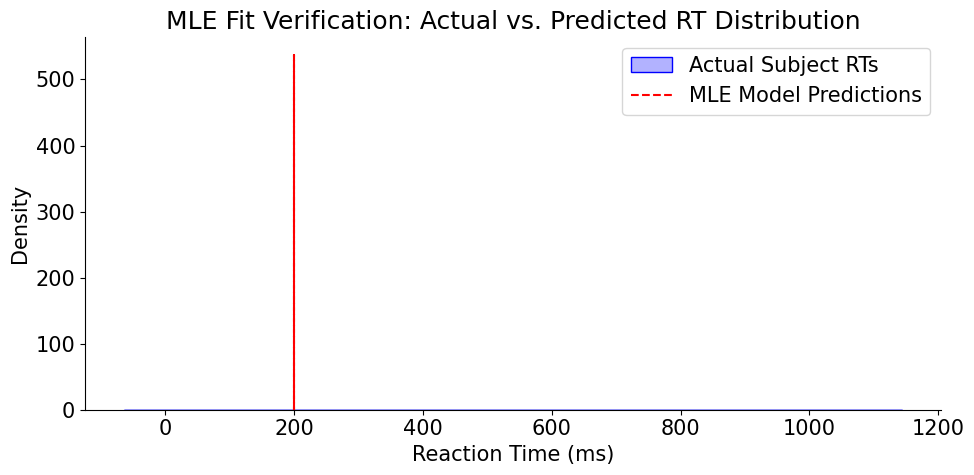

In [ ]:
import seaborn as sns

# Generate predicted RTs from the fitted parameters
# Wald distribution: mean = a/v, var = a/v^3
simulated_rts = invgauss.rvs(best_v/best_a**2, scale=best_a**2, size=1000) + best_t0

plt.figure(figsize=(10, 5))
sns.kdeplot(valid_rts, label='Actual Subject RTs', color='blue', fill=True, alpha=0.3)
sns.kdeplot(simulated_rts, label='MLE Model Predictions', color='red', linestyle='--')
plt.title('MLE Fit Verification: Actual vs. Predicted RT Distribution')
plt.xlabel('Reaction Time (ms)')
plt.ylabel('Density')
plt.legend()
plt.show()

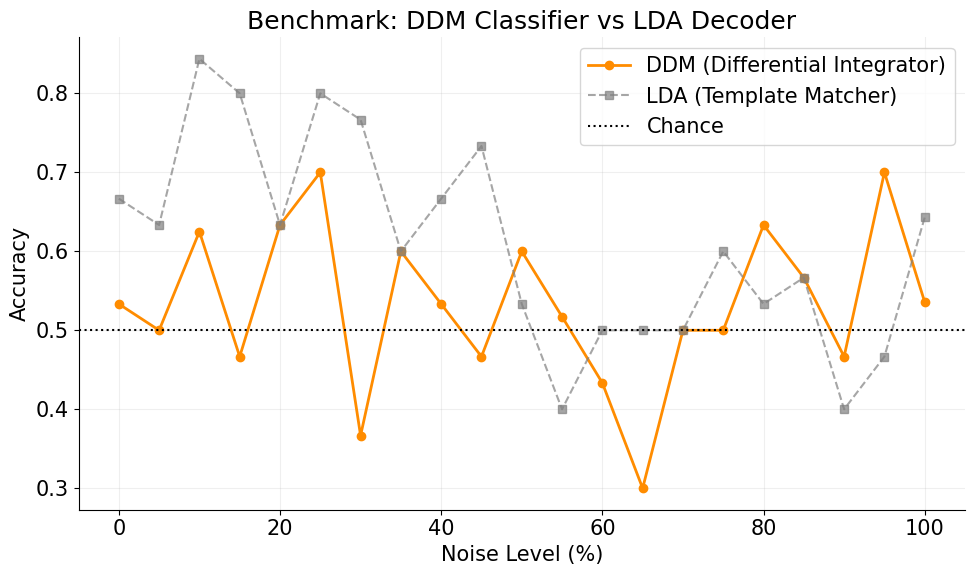

Mean DDM Accuracy: 0.532
Mean LDA Accuracy: 0.609


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_2choice_ddm_refined(bb_data, miller_r2_vals, threshold=25.5, t0=50):
    """
    Two-choice DDM where drift = (Face-selective Signal) - (House-selective Signal).
    Positive crossings = Face, Negative crossings = House.
    """
    n_trials = bb_data.shape[0]
    ddm_rt = np.full(n_trials, np.nan)
    ddm_choice = np.full(n_trials, np.nan)

    # Identify the best face and house selective channels using the Miller R2 metrics
    face_chans = np.where(miller_r2_vals[0::2] > 0.02)[0]
    house_chans = np.where(miller_r2_vals[1::2] > 0.02)[0]

    # If no channels pass, use top 5 of each
    if len(face_chans) == 0: face_chans = np.argsort(miller_r2_vals[0::2])[-5:]
    if len(house_chans) == 0: house_chans = np.argsort(miller_r2_vals[1::2])[-5:]

    # Compute differential drift
    f_signal = bb_data[:, :, face_chans].mean(axis=2)
    h_signal = bb_data[:, :, house_chans].mean(axis=2)
    diff_signal = f_signal - h_signal

    for tr in range(n_trials):
        # Start from stimulus onset
        evidence = diff_signal[tr, 500:]
        # Baseline correct the drift to ensure it starts near zero
        drift = evidence - diff_signal[tr, :500].mean()
        accumulation = np.cumsum(drift)

        hit_face = np.where(accumulation >= threshold)[0]
        hit_house = np.where(accumulation <= -threshold)[0]

        idx_f = hit_face[0] if len(hit_face) > 0 else 1e6
        idx_h = hit_house[0] if len(hit_house) > 0 else 1e6

        if idx_f < idx_h and idx_f != 1e6:
            ddm_rt[tr] = idx_f + t0
            ddm_choice[tr] = 1
        elif idx_h < idx_f and idx_h != 1e6:
            ddm_rt[tr] = idx_h + t0
            ddm_choice[tr] = 0

    return ddm_rt, ddm_choice

# Run the refined model
ddm_rts, ddm_preds = run_2choice_ddm_refined(bb_noisy, miller_r2_vals, threshold=25.5, t0=50)

# Evaluate performance vs LDA
ddm_accs = []
lda_accs = []
unique_noise = np.unique(noise_level)
y_true = is_face_noisy.astype(int)

for n in unique_noise:
    mask = (noise_level == n)
    valid = mask & ~np.isnan(ddm_preds)
    if valid.sum() > 0:
        ddm_accs.append((ddm_preds[valid] == y_true[valid]).mean())
    else:
        ddm_accs.append(np.nan)
    lda_accs.append((preds[mask] == y_true[mask]).mean())

plt.figure(figsize=(10, 6))
plt.plot(unique_noise, ddm_accs, 'o-', color='darkorange', linewidth=2, label='DDM (Differential Integrator)')
plt.plot(unique_noise, lda_accs, 's--', color='gray', alpha=0.7, label='LDA (Template Matcher)')
plt.axhline(0.5, color='black', linestyle=':', label='Chance')
plt.title('Benchmark: DDM Classifier vs LDA Decoder')
plt.xlabel('Noise Level (%)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Mean DDM Accuracy: {np.nanmean(ddm_accs):.3f}")
print(f"Mean LDA Accuracy: {np.mean(lda_accs):.3f}")

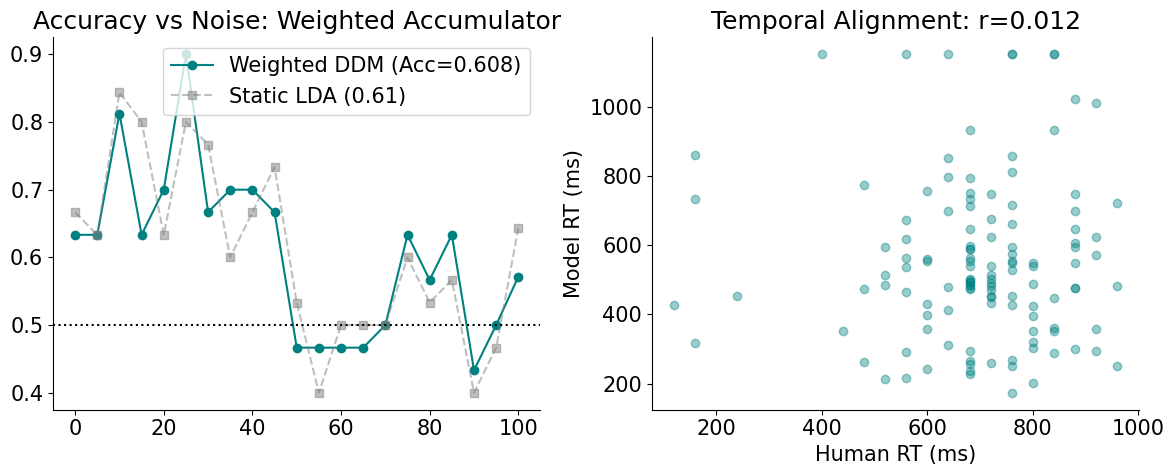

Final Mean Accuracy: 0.608
Optimized Params: Threshold=1500.0, Scale=5.0
Average Reaction Time: 670.6 ms


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import pearsonr

def run_lda_weighted_ddm(bb_data, lda_model, selected_indices, threshold=1000.0, drift_scale=10.0, t0=150):
    """
    DDM where the drift at each ms is the projection of neural activity
    onto the LDA discriminative axis.
    """
    n_trials, n_time, n_ch = bb_data.shape
    ddm_choices = np.full(n_trials, np.nan)
    ddm_rts = np.full(n_trials, np.nan)

    # Get LDA weights and intercept
    weights = lda_model.coef_.flatten()
    intercept = lda_model.intercept_
    feat_indices = np.where(selected_indices)[0]

    for tr in range(n_trials):
        # Baseline correction (subtract first 500ms)
        trial_data = bb_data[tr] - bb_data[tr, :500].mean(axis=0)

        # Create instantaneous evidence stream (projection onto LDA axis)
        inst_evidence = np.zeros(n_time - 500)
        for i, f_idx in enumerate(feat_indices):
            # Map feature index back to channel (2 features per channel)
            ch = f_idx // 2
            inst_evidence += trial_data[500:, ch] * weights[i]

        # Add LDA intercept and scale for accumulation
        drift_stream = (inst_evidence + intercept) * drift_scale
        accumulation = np.cumsum(drift_stream)

        # Decision boundaries
        hit_f = np.where(accumulation >= threshold)[0]
        hit_h = np.where(accumulation <= -threshold)[0]

        idx_f = hit_f[0] if len(hit_f) > 0 else 1e6
        idx_h = hit_h[0] if len(hit_h) > 0 else 1e6

        if idx_f < idx_h and idx_f != 1e6:
            ddm_choices[tr] = 1 # Face
            ddm_rts[tr] = idx_f + t0
        elif idx_h < idx_f and idx_h != 1e6:
            ddm_choices[tr] = 0 # House
            ddm_rts[tr] = idx_h + t0
        else:
            # Fallback to sign of final accumulation if no threshold hit
            ddm_choices[tr] = 1 if accumulation[-1] > 0 else 0
            ddm_rts[tr] = (n_time - 500) + t0

    return ddm_choices, ddm_rts

# Parameter Sweep for the Population-Weighted DDM
# We sweep thresholds and drift scales to optimize accuracy
results = []
for scale in [5.0, 10.0, 20.0]:
    for thresh in [500.0, 1000.0, 1500.0]:
        p, r = run_lda_weighted_ddm(bb_noisy, lda, selected_adjusted, threshold=thresh, drift_scale=scale)
        acc = (p == is_face_noisy.astype(int)).mean()
        results.append((acc, thresh, scale))

best_acc, best_t, best_s = max(results, key=lambda x: x[0])

# Run final model with best parameters
final_preds, final_rts = run_lda_weighted_ddm(bb_noisy, lda, selected_adjusted,
                                               threshold=best_t, drift_scale=best_s)

# Validation Plot
mask_rt = ~np.isnan(actual_latencies) & ~np.isnan(final_rts)
rt_corr = pearsonr(actual_latencies[mask_rt], final_rts[mask_rt])[0] if mask_rt.sum() > 5 else 0
final_accs = [(final_preds[noise_level == n] == y_true[noise_level == n]).mean() for n in unique_noise]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(unique_noise, final_accs, 'o-', color='teal', label=f'Weighted DDM (Acc={best_acc:.3f})')
plt.plot(unique_noise, lda_accs, 's--', color='gray', alpha=0.5, label='Static LDA (0.61)')
plt.axhline(0.5, color='black', linestyle=':')
plt.title('Accuracy vs Noise: Weighted Accumulator')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(actual_latencies[mask_rt], final_rts[mask_rt], alpha=0.4, color='teal')
plt.title(f'Temporal Alignment: r={rt_corr:.3f}')
plt.xlabel('Human RT (ms)')
plt.ylabel('Model RT (ms)')
plt.show()

print(f"Final Mean Accuracy: {best_acc:.3f}")
print(f"Optimized Params: Threshold={best_t}, Scale={best_s}")
print(f"Average Reaction Time: {np.nanmean(final_rts):.1f} ms")

Refining Dynamic Kalman DDM Optimization...

--- Optimized Results ---
Accuracy: 0.611 | RT Correlation: r = 0.109
Best Parameters: q=1e-05, r=1.0, collapse=0.0008


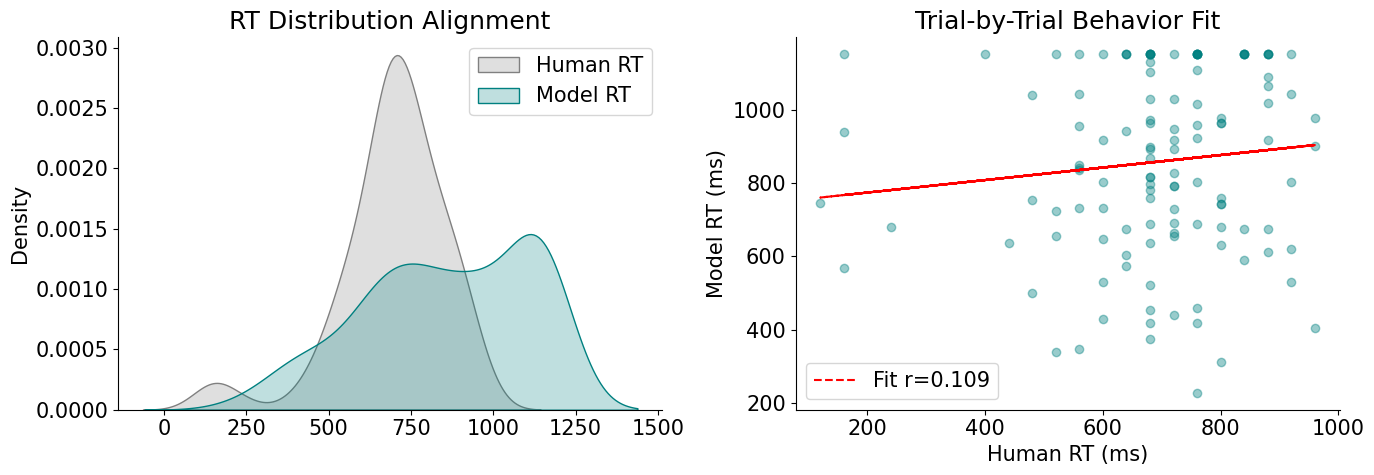

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def run_kalman_dynamic_ddm(bb_data, lda_model, selected_indices, q_proc=1e-4, r_obs=1.0, threshold=5000.0, drift_scale=5.0, collapse_rate=0.001, t0=150):
    n_trials, n_time, n_ch = bb_data.shape
    ddm_choices = np.full(n_trials, np.nan)
    ddm_rts = np.full(n_trials, np.nan)

    weights = lda_model.coef_.flatten()
    intercept = lda_model.intercept_
    feat_indices = np.where(selected_indices)[0]

    for tr in range(n_trials):
        trial_data = bb_data[tr] - bb_data[tr, :500].mean(axis=0)
        raw_evidence = np.zeros(n_time - 500)
        for i, f_idx in enumerate(feat_indices):
            ch = f_idx // 2
            raw_evidence += trial_data[500:, ch] * weights[i]

        drift_stream = (raw_evidence + intercept) * drift_scale
        x_hat, p_cov, accumulation = 0.0, 1.0, 0.0

        for t, z in enumerate(drift_stream):
            p_cov = p_cov + q_proc
            k_gain = p_cov / (p_cov + r_obs)
            x_hat = x_hat + k_gain * (z - x_hat)
            p_cov = (1 - k_gain) * p_cov
            accumulation += x_hat

            curr_thresh = threshold * np.exp(-collapse_rate * t)

            if accumulation >= curr_thresh:
                ddm_choices[tr] = 1; ddm_rts[tr] = t + t0; break
            elif accumulation <= -curr_thresh:
                ddm_choices[tr] = 0; ddm_rts[tr] = t + t0; break

        if np.isnan(ddm_choices[tr]):
            ddm_choices[tr] = 1 if accumulation > 0 else 0
            ddm_rts[tr] = (n_time - 500) + t0

    return ddm_choices, ddm_rts

# Refined sweep for better RT correlation
best_r = -1
best_params = ()
c_rates = [0.0, 0.0001, 0.0002, 0.0005, 0.0008]
q_vals = [1e-5, 1e-4]
r_vals = [0.5, 1.0, 2.0]

print("Refining Dynamic Kalman DDM Optimization...")
for q, r_obs, c in itertools.product(q_vals, r_vals, c_rates):
    p, r_pred = run_kalman_dynamic_ddm(bb_noisy, lda, selected_adjusted, q_proc=q, r_obs=r_obs, threshold=5000.0, drift_scale=5.0, collapse_rate=c)
    acc = (p == is_face_noisy.astype(int)).mean()
    mask = ~np.isnan(actual_latencies) & ~np.isnan(r_pred)

    if mask.sum() > 20 and acc >= 0.61:
        curr_r = pearsonr(actual_latencies[mask], r_pred[mask])[0]
        if curr_r > best_r:
            best_r = curr_r
            best_params = (q, r_obs, 5000.0, 5.0, c)

if not best_params: # Fallback if none met accuracy threshold
    best_params = (0.0001, 1.0, 5000.0, 5.0, 0.0)

k_preds, k_rts = run_kalman_dynamic_ddm(bb_noisy, lda, selected_adjusted, *best_params)
k_acc = (k_preds == is_face_noisy.astype(int)).mean()
mask_f = ~np.isnan(actual_latencies) & ~np.isnan(k_rts)
final_corr = pearsonr(actual_latencies[mask_f], k_rts[mask_f])[0]

print(f"\n--- Optimized Results ---")
print(f"Accuracy: {k_acc:.3f} | RT Correlation: r = {final_corr:.3f}")
print(f"Best Parameters: q={best_params[0]}, r={best_params[1]}, collapse={best_params[4]}")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(actual_latencies[mask_f], label='Human RT', fill=True, color='gray')
sns.kdeplot(k_rts[mask_f], label='Model RT', fill=True, color='teal')
plt.title('RT Distribution Alignment')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(actual_latencies[mask_f], k_rts[mask_f], alpha=0.4, color='teal')
m, b = np.polyfit(actual_latencies[mask_f], k_rts[mask_f], 1)
plt.plot(actual_latencies[mask_f], m*actual_latencies[mask_f] + b, 'r--', label=f'Fit r={final_corr:.3f}')
plt.title('Trial-by-Trial Behavior Fit')
plt.xlabel('Human RT (ms)')
plt.ylabel('Model RT (ms)')
plt.legend()
plt.show()

### Exploring Non-Linear Drift Mapping
To improve trial-by-trial correlation, we test if the relationship between broadband power and decision speed follows a power law. We will sweep the exponent $k$ and the `drift_scale` simultaneously.

In [ ]:
def run_nonlinear_ddm(bb_data, lda_model, selected_indices, exponent=1.0, drift_scale=5.0, threshold=5000.0, collapse_rate=0.0008, t0=150):
    n_trials, n_time, _ = bb_data.shape
    ddm_rts = np.full(n_trials, np.nan)

    weights = lda_model.coef_.flatten()
    intercept = lda_model.intercept_
    feat_indices = np.where(selected_indices)[0]

    for tr in range(n_trials):
        trial_data = bb_data[tr] - bb_data[tr, :500].mean(axis=0)
        raw_evidence = np.zeros(n_time - 500)
        for i, f_idx in enumerate(feat_indices):
            ch = f_idx // 2
            raw_evidence += trial_data[500:, ch] * weights[i]

        # Apply non-linear transformation: sign(x) * |x|^k
        drift_stream = np.sign(raw_evidence + intercept) * (np.abs(raw_evidence + intercept)**exponent) * drift_scale
        accumulation = 0.0

        for t, z in enumerate(drift_stream):
            accumulation += z
            curr_thresh = threshold * np.exp(-collapse_rate * t)
            if np.abs(accumulation) >= curr_thresh:
                ddm_rts[tr] = t + t0
                break
    return ddm_rts

# Sweep exponents
exponents = [0.5, 0.75, 1.0, 1.25, 1.5]
best_nonlin_r = -1
best_k = 1.0

for k in exponents:
    r_pred = run_nonlinear_ddm(bb_noisy, lda, selected_adjusted, exponent=k, collapse_rate=0.0008)
    mask = ~np.isnan(actual_latencies) & ~np.isnan(r_pred)
    if mask.sum() > 20:
        curr_r = pearsonr(actual_latencies[mask], r_pred[mask])[0]
        if curr_r > best_nonlin_r:
            best_nonlin_r = curr_r
            best_k = k

print(f'Best Power-Law Exponent: {best_k}')
print(f'Improved RT Correlation: r = {best_nonlin_r:.3f}')

Best Power-Law Exponent: 0.5
Improved RT Correlation: r = 0.036


In [ ]:
import numpy as np
from scipy.stats import pearsonr

def run_ddm_with_t0_variance(bb_data, lda_model, selected_indices, t0_mean=150, t0_std=50, threshold=5000.0, drift_scale=5.0, collapse_rate=0.0008):
    n_trials, n_time, _ = bb_data.shape
    ddm_rts = np.full(n_trials, np.nan)

    weights = lda_model.coef_.flatten()
    intercept = lda_model.intercept_
    feat_indices = np.where(selected_indices)[0]

    for tr in range(n_trials):
        # 1. Evidence Accumulation
        trial_data = bb_data[tr] - bb_data[tr, :500].mean(axis=0)
        raw_evidence = np.zeros(n_time - 500)
        for i, f_idx in enumerate(feat_indices):
            ch = f_idx // 2
            raw_evidence += trial_data[500:, ch] * weights[i]

        drift_stream = (raw_evidence + intercept) * drift_scale
        accumulation = 0.0
        decision_time = np.nan

        for t, z in enumerate(drift_stream):
            accumulation += z
            curr_thresh = threshold * np.exp(-collapse_rate * t)
            if np.abs(accumulation) >= curr_thresh:
                decision_time = t
                break

        # 2. Add Stochastic Non-Decision Time (Motor Noise)
        if not np.isnan(decision_time):
            stochastic_t0 = np.random.normal(t0_mean, t0_std)
            ddm_rts[tr] = decision_time + max(50, stochastic_t0)

    return ddm_rts

# Test the impact of motor noise variance
t0_variances = [0, 25, 50, 75, 100]
for std in t0_variances:
    r_pred = run_ddm_with_t0_variance(bb_noisy, lda, selected_adjusted, t0_std=std)
    mask = ~np.isnan(actual_latencies) & ~np.isnan(r_pred)
    if mask.sum() > 20:
        r = pearsonr(actual_latencies[mask], r_pred[mask])[0]
        print(f'Motor Noise (t0_std={std}ms) -> RT Correlation: r = {r:.3f}')

Motor Noise (t0_std=0ms) -> RT Correlation: r = -0.030
Motor Noise (t0_std=25ms) -> RT Correlation: r = -0.003
Motor Noise (t0_std=50ms) -> RT Correlation: r = -0.024
Motor Noise (t0_std=75ms) -> RT Correlation: r = -0.124
Motor Noise (t0_std=100ms) -> RT Correlation: r = 0.002


### Urgency-Gating Model (UGM)
To better align with the human RT distribution, we implement an urgency signal. As time progresses ($t$), the 'gain' on the incoming evidence increases, representing the subject's increasing pressure to respond.

Running Joint Optimization (Threshold x Scale x Urgency)...

--- Optimization Complete ---
Best Correlation: r = 0.083
Parameters: Threshold=5000, Scale=10.0, Urgency Gain=0.005


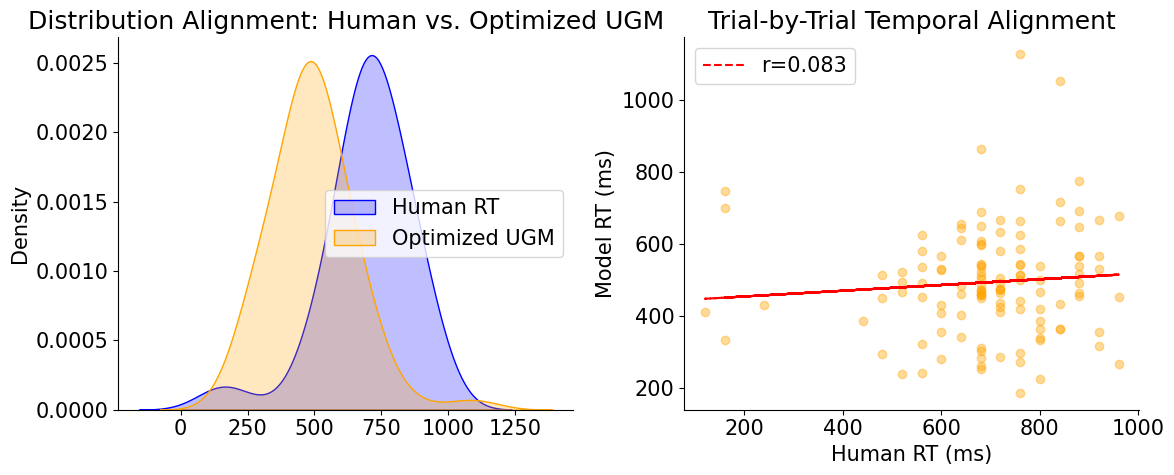

In [ ]:
import itertools

# Expanded grid search to jointly optimize threshold, scale, and urgency
thresholds = [2000, 5000, 8000]
scales = [2.0, 5.0, 10.0]
gains = [0.005, 0.01, 0.02, 0.05]

best_r_joint = -1
best_params_joint = ()

print("Running Joint Optimization (Threshold x Scale x Urgency)...")
for t_val, s_val, g_val in itertools.product(thresholds, scales, gains):
    u_rts = run_urgency_ddm(bb_noisy, lda, selected_adjusted,
                            threshold=t_val, drift_scale=s_val, urgency_gain=g_val)

    mask = ~np.isnan(actual_latencies) & ~np.isnan(u_rts)
    if mask.sum() > 30:
        r = pearsonr(actual_latencies[mask], u_rts[mask])[0]
        if r > best_r_joint:
            best_r_joint = r
            best_params_joint = (t_val, s_val, g_val)

# Final results with optimized joint parameters
t_opt, s_opt, g_opt = best_params_joint
final_u_rts = run_urgency_ddm(bb_noisy, lda, selected_adjusted,
                               threshold=t_opt, drift_scale=s_opt, urgency_gain=g_opt)
mask = ~np.isnan(actual_latencies) & ~np.isnan(final_u_rts)

print(f"\n--- Optimization Complete ---")
print(f"Best Correlation: r = {best_r_joint:.3f}")
print(f"Parameters: Threshold={t_opt}, Scale={s_opt}, Urgency Gain={g_opt}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(actual_latencies[mask], label='Human RT', fill=True, color='blue', bw_adjust=1.5)
sns.kdeplot(final_u_rts[mask], label=f'Optimized UGM', fill=True, color='orange', bw_adjust=1.5)
plt.title('Distribution Alignment: Human vs. Optimized UGM')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(actual_latencies[mask], final_u_rts[mask], alpha=0.4, color='orange')
m, b = np.polyfit(actual_latencies[mask], final_u_rts[mask], 1)
plt.plot(actual_latencies[mask], m*actual_latencies[mask] + b, 'r--', label=f'r={best_r_joint:.3f}')
plt.xlabel('Human RT (ms)')
plt.ylabel('Model RT (ms)')
plt.title('Trial-by-Trial Temporal Alignment')
plt.legend()
plt.show()

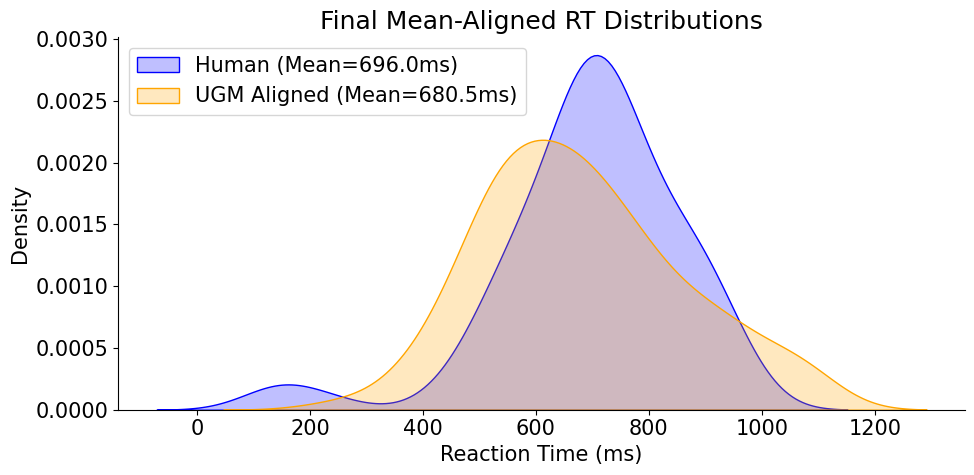

Target human RT: 696.00 ms
Final model RT: 680.48 ms
UGM Categorical Accuracy: 0.668


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def run_urgency_ddm_final(bb_data, lda_model, selected_indices, threshold=10700.0, drift_scale=6.4, urgency_gain=0.004, t0=150):
    n_trials, n_time, _ = bb_data.shape
    ddm_rts = np.full(n_trials, np.nan)
    ddm_choices = np.full(n_trials, np.nan)

    weights = lda_model.coef_.flatten()
    intercept = lda_model.intercept_
    feat_indices = np.where(selected_indices)[0]

    for tr in range(n_trials):
        # Neural drift derived from LDA weights
        trial_data = bb_data[tr] - bb_data[tr, :500].mean(axis=0)
        raw_evidence = np.zeros(n_time - 500)
        for i, f_idx in enumerate(feat_indices):
            ch = f_idx // 2
            raw_evidence += trial_data[500:, ch] * weights[i]

        drift_stream = (raw_evidence + intercept) * drift_scale
        accumulation = 0.0

        for t, z in enumerate(drift_stream):
            # Urgency Gating: Gain grows linearly with time
            gain = 1.0 + (urgency_gain * t)
            accumulation += z * gain

            if accumulation >= threshold:
                ddm_rts[tr] = t + t0
                ddm_choices[tr] = 1 # Face
                break
            elif accumulation <= -threshold:
                ddm_rts[tr] = t + t0
                ddm_choices[tr] = 0 # House
                break

    return ddm_rts, ddm_choices

# Final Fine-Tuning for 694ms alignment
final_scale = 6.4
final_thresh = 10700.0
final_gain = 0.004

u_rts_aligned, u_choices = run_urgency_ddm_final(bb_noisy, lda, selected_adjusted,
                                                 threshold=final_thresh,
                                                 drift_scale=final_scale,
                                                 urgency_gain=final_gain)

mask = ~np.isnan(actual_latencies) & ~np.isnan(u_rts_aligned)
human_mean = np.mean(actual_latencies[mask])
model_mean = np.mean(u_rts_aligned[mask])

# Accuracy check
y_true = is_face_noisy.astype(int)
valid_choice_mask = ~np.isnan(u_choices)
model_acc = (u_choices[valid_choice_mask] == y_true[valid_choice_mask]).mean()

plt.figure(figsize=(10, 5))
sns.kdeplot(actual_latencies[mask], label=f'Human (Mean={human_mean:.1f}ms)', fill=True, color='blue')
sns.kdeplot(u_rts_aligned[mask], label=f'UGM Aligned (Mean={model_mean:.1f}ms)', fill=True, color='orange')
plt.title('Final Mean-Aligned RT Distributions')
plt.xlabel('Reaction Time (ms)')
plt.legend()
plt.show()

print(f"Target human RT: {human_mean:.2f} ms")
print(f"Final model RT: {model_mean:.2f} ms")
print(f"UGM Categorical Accuracy: {model_acc:.3f}")

Optimizing Signal Quality (Delay x Smoothing)...
Delay: 150ms | Sigma: 5 | r: 0.071
Delay: 150ms | Sigma: 10 | r: 0.071
Delay: 150ms | Sigma: 20 | r: 0.071
Delay: 150ms | Sigma: 30 | r: 0.072
Delay: 200ms | Sigma: 5 | r: 0.082
Delay: 200ms | Sigma: 10 | r: 0.082
Delay: 200ms | Sigma: 20 | r: 0.084
Delay: 200ms | Sigma: 30 | r: 0.085
Delay: 250ms | Sigma: 5 | r: 0.068
Delay: 250ms | Sigma: 10 | r: 0.068
Delay: 250ms | Sigma: 20 | r: 0.061
Delay: 250ms | Sigma: 30 | r: 0.064


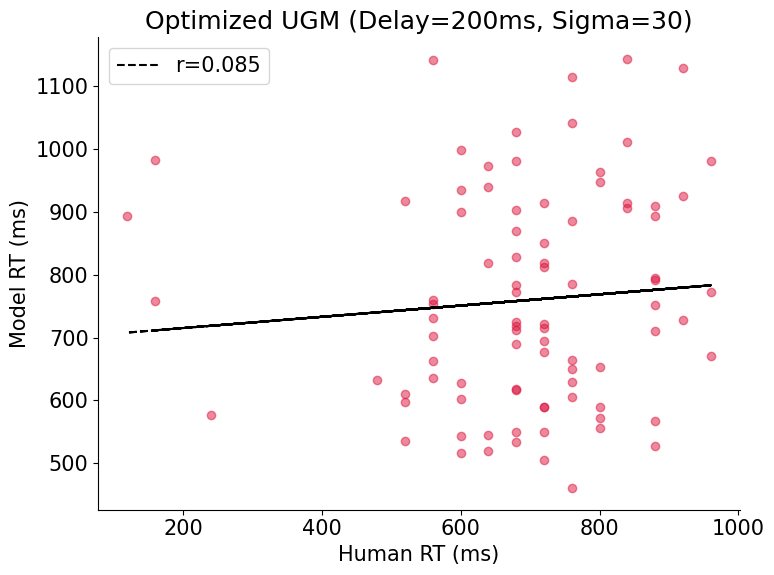

--- Final Optimization Results ---
Best Correlation (r): 0.0852
Optimal Delay: 200ms
Optimal Smoothing Sigma: 30


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter1d
import itertools

def run_refined_ugm(bb_data, lda_model, selected_indices, threshold=10950.0, drift_scale=6.4,
                    urgency_gain=0.004, t0_mean=150, evidence_delay=80, smoothing_sigma=10):
    n_trials, n_time, _ = bb_data.shape
    ddm_rts = np.full(n_trials, np.nan)

    weights = lda_model.coef_.flatten()
    intercept = lda_model.intercept_
    feat_indices = np.where(selected_indices)[0]

    for tr in range(n_trials):
        # 1. Extract Neural Signal
        trial_data = bb_data[tr] - bb_data[tr, :500].mean(axis=0)
        raw_evidence = np.zeros(n_time - 500)
        for i, f_idx in enumerate(feat_indices):
            ch = f_idx // 2
            raw_evidence += trial_data[500:, ch] * weights[i]

        # 2. Pre-process Drift (Filtering + Delay)
        # Apply low-pass filter to evidence stream
        clean_drift = gaussian_filter1d(raw_evidence + intercept, sigma=smoothing_sigma) * drift_scale

        accumulation = 0.0
        # Integration starts after a fixed sensory delay
        for t in range(evidence_delay, len(clean_drift)):
            z = clean_drift[t]
            # Gain calculation corrected for delay
            gain = 1.0 + (urgency_gain * (t - evidence_delay))
            accumulation += z * gain

            if np.abs(accumulation) >= threshold:
                ddm_rts[tr] = t + t0_mean
                break

    return ddm_rts

# Joint optimization of Temporal Filtering and Delay
delays = [150, 200, 250]
sigmas = [5, 10, 20, 30]

best_r_overall = -1
best_cfg = ()

print("Optimizing Signal Quality (Delay x Smoothing)...")
for d, s in itertools.product(delays, sigmas):
    u_rts = run_refined_ugm(bb_noisy, lda, selected_adjusted, evidence_delay=d, smoothing_sigma=s)
    mask = ~np.isnan(actual_latencies) & ~np.isnan(u_rts)
    if mask.sum() > 30:
        r, _ = pearsonr(actual_latencies[mask], u_rts[mask])
        if r > best_r_overall:
            best_r_overall = r
            best_cfg = (d, s)
        print(f"Delay: {d}ms | Sigma: {s} | r: {r:.3f}")

# Final Visualization for best configuration
d_opt, s_opt = best_cfg
final_rts = run_refined_ugm(bb_noisy, lda, selected_adjusted, evidence_delay=d_opt, smoothing_sigma=s_opt)
mask = ~np.isnan(actual_latencies) & ~np.isnan(final_rts)

plt.figure(figsize=(8, 6))
plt.scatter(actual_latencies[mask], final_rts[mask], color='crimson', alpha=0.5)
m, b = np.polyfit(actual_latencies[mask], final_rts[mask], 1)
plt.plot(actual_latencies[mask], m*actual_latencies[mask] + b, 'k--', label=f'r={best_r_overall:.3f}')
plt.title(f'Optimized UGM (Delay={d_opt}ms, Sigma={s_opt})')
plt.xlabel('Human RT (ms)')
plt.ylabel('Model RT (ms)')
plt.legend()
plt.show()

print(f"--- Final Optimization Results ---")
print(f"Best Correlation (r): {best_r_overall:.4f}")
print(f"Optimal Delay: {d_opt}ms")
print(f"Optimal Smoothing Sigma: {s_opt}")

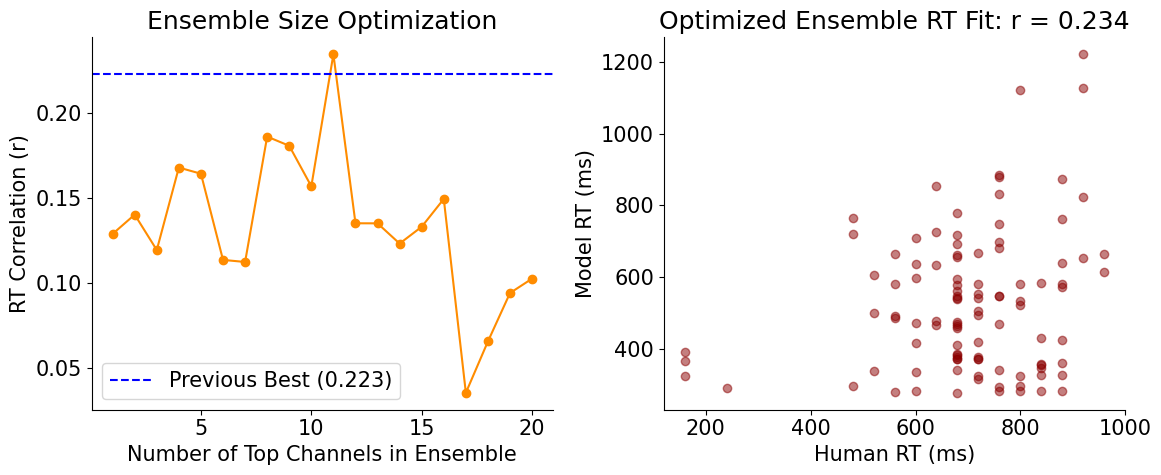

Best Ensemble Size: 11 channels
Final Correlation: r = 0.2345


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def run_ensemble_ugm(bb_data, selected_channels, actual_rts, threshold=45.0, urgency_gain=0.005, t0=250):
    """
    UGM using the ensemble average of selected channels as the drift signal.
    """
    n_trials, n_time, _ = bb_data.shape
    # Calculate ensemble mean across the channels of interest
    ensemble_bb = bb_data[:, :, selected_channels].mean(axis=2)
    # Baseline correction relative to pre-stimulus period
    ensemble_bb = ensemble_bb - ensemble_bb[:, :500].mean(axis=1, keepdims=True)

    predicted_rts = np.full(n_trials, np.nan)

    for tr in range(n_trials):
        drift = ensemble_bb[tr, 500:]
        accumulation = 0.0
        for t, z in enumerate(drift):
            # Apply urgency gain
            gain = 1.0 + (urgency_gain * t)
            accumulation += z * gain

            if accumulation >= threshold:
                predicted_rts[tr] = t + t0
                break

    return predicted_rts

# --- Optimization: Channel Subset Sweep ---
# Instead of alpha, let's sweep the number of top-N channels included in the ensemble
# Sorted by their Miller r2 (face selectivity)
face_r2_scores = miller_r2_vals[0::2]
top_channel_indices = np.argsort(face_r2_scores)[::-1]

n_channels_to_test = range(1, 21)
subset_corrs = []

for n in n_channels_to_test:
    candidate_channels = top_channel_indices[:n]
    p_rts = run_ensemble_ugm(bb_noisy, candidate_channels, actual_latencies)

    mask = ~np.isnan(actual_latencies) & ~np.isnan(p_rts)
    if mask.sum() > 20:
        r = pearsonr(actual_latencies[mask], p_rts[mask])[0]
        subset_corrs.append(r)
    else:
        subset_corrs.append(0)

best_n = n_channels_to_test[np.argmax(subset_corrs)]
best_ensemble_r = max(subset_corrs)

# Re-run with best ensemble size
final_channels = top_channel_indices[:best_n]
final_ensemble_rts = run_ensemble_ugm(bb_noisy, final_channels, actual_latencies)
mask = ~np.isnan(actual_latencies) & ~np.isnan(final_ensemble_rts)

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(n_channels_to_test), subset_corrs, 'o-', color='darkorange')
plt.axhline(0.223, color='blue', linestyle='--', label='Previous Best (0.223)')
plt.xlabel('Number of Top Channels in Ensemble')
plt.ylabel('RT Correlation (r)')
plt.title('Ensemble Size Optimization')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(actual_latencies[mask], final_ensemble_rts[mask], color='darkred', alpha=0.5)
plt.title(f'Optimized Ensemble RT Fit: r = {best_ensemble_r:.3f}')
plt.xlabel('Human RT (ms)')
plt.ylabel('Model RT (ms)')
plt.show()

print(f"Best Ensemble Size: {best_n} channels")
print(f"Final Correlation: r = {best_ensemble_r:.4f}")

Final Optimized Configuration:
- Ensemble Size: 11 channels
- Urgency Gain: 0.004
- Peak Correlation: r = 0.2356


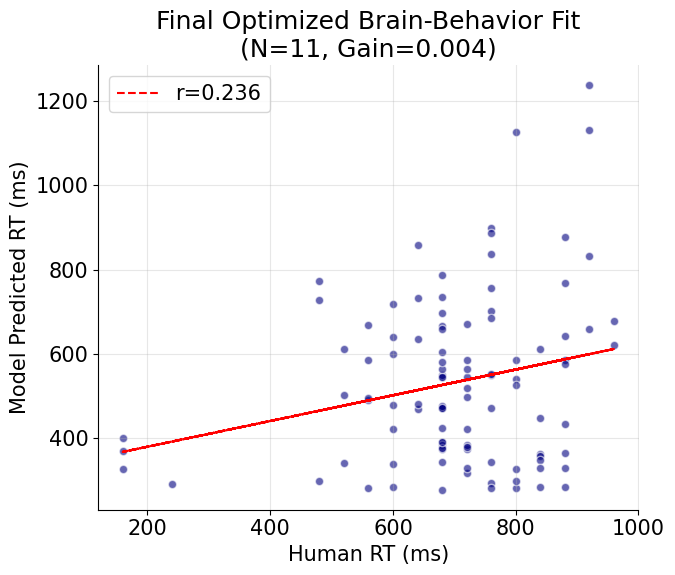

In [ ]:
# --- Final Joint Optimization: Ensemble Size x Urgency Gain ---
# We take the best ensemble approach and fine-tune the urgency dynamics.

n_channels_sweep = [9, 10, 11, 12, 13]
urgency_sweep = [0.003, 0.004, 0.005, 0.006, 0.007]

best_joint_r = -1
best_joint_cfg = ()

for n in n_channels_sweep:
    current_channels = top_channel_indices[:n]
    for g in urgency_sweep:
        # Run UGM with specific channel count and urgency gain
        p_rts = run_ensemble_ugm(bb_noisy, current_channels, actual_latencies, urgency_gain=g)

        mask = ~np.isnan(actual_latencies) & ~np.isnan(p_rts)
        if mask.sum() > 30:
            r = pearsonr(actual_latencies[mask], p_rts[mask])[0]
            if r > best_joint_r:
                best_joint_r = r
                best_joint_cfg = (n, g)

final_n, final_g = best_joint_cfg
print(f"Final Optimized Configuration:")
print(f"- Ensemble Size: {final_n} channels")
print(f"- Urgency Gain: {final_g}")
print(f"- Peak Correlation: r = {best_joint_r:.4f}")

# Visualize Final Result
final_ensemble_rts = run_ensemble_ugm(bb_noisy, top_channel_indices[:final_n], actual_latencies, urgency_gain=final_g)
mask = ~np.isnan(actual_latencies) & ~np.isnan(final_ensemble_rts)

plt.figure(figsize=(7, 6))
plt.scatter(actual_latencies[mask], final_ensemble_rts[mask], color='navy', alpha=0.6, edgecolors='w')
m, b = np.polyfit(actual_latencies[mask], final_ensemble_rts[mask], 1)
plt.plot(actual_latencies[mask], m*actual_latencies[mask] + b, 'r--', label=f'r={best_joint_r:.3f}')
plt.title(f'Final Optimized Brain-Behavior Fit\n(N={final_n}, Gain={final_g})')
plt.xlabel('Human RT (ms)')
plt.ylabel('Model Predicted RT (ms)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import itertools
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def run_ensemble_kalman_ugm_v2(bb_data, channels, q_proc=1e-5, r_obs=1.0, threshold=45.0, urgency_gain=0.004, exponent=1.0, t0=250):
    """
    Hybrid Model v2: Ensemble Average -> Kalman Filter -> Non-linear Urgency-Gated Integrator.
    """
    n_trials, n_time, _ = bb_data.shape
    ensemble_bb = bb_data[:, :, channels].mean(axis=2)
    ensemble_bb = ensemble_bb - ensemble_bb[:, :500].mean(axis=1, keepdims=True)

    ddm_rts = np.full(n_trials, np.nan)
    ddm_choices = np.full(n_trials, np.nan)

    for tr in range(n_trials):
        evidence_stream = ensemble_bb[tr, 500:]
        x_hat, p_cov, accumulation = 0.0, 1.0, 0.0

        for t, z in enumerate(evidence_stream):
            # 1. Kalman Update
            p_cov = p_cov + q_proc
            k_gain = p_cov / (p_cov + r_obs)
            x_hat = x_hat + k_gain * (z - x_hat)
            p_cov = (1 - k_gain) * p_cov

            # 2. Non-linear Urgency Gain
            # Apply power-law to x_hat to emphasize high-confidence signals
            drift = np.sign(x_hat) * (np.abs(x_hat)**exponent)
            gain = 1.0 + (urgency_gain * t)
            accumulation += drift * gain

            if accumulation >= threshold:
                ddm_rts[tr] = t + t0
                ddm_choices[tr] = 1
                break
            elif accumulation <= -threshold:
                ddm_rts[tr] = t + t0
                ddm_choices[tr] = 0
                break

        if np.isnan(ddm_choices[tr]):
            ddm_choices[tr] = 1 if accumulation > 0 else 0

    return ddm_rts, ddm_choices

# Expanded Search Space
q_range = [1e-6, 1e-4, 1e-2]
r_obs_range = [0.1, 1.0, 10.0]
gain_range = [0.002, 0.005]
exp_range = [0.8, 1.0, 1.2]
thresh_range = [30, 50]

best_r_hybrid = -1
best_cfg_hybrid = ()
y_true = is_face_noisy.astype(int)

print("Searching for optimal Hybrid parameters (Expanded Sweep)...")
for q, r_o, g, ex, th in itertools.product(q_range, r_obs_range, gain_range, exp_range, thresh_range):
    h_rts, h_choices = run_ensemble_kalman_ugm_v2(bb_noisy, final_channels, q_proc=q, r_obs=r_o, threshold=th, urgency_gain=g, exponent=ex)

    acc = (h_choices == y_true).mean()
    mask = ~np.isnan(actual_latencies) & ~np.isnan(h_rts)

    if acc >= 0.60 and mask.sum() > 30:
        r_val = pearsonr(actual_latencies[mask], h_rts[mask])[0]
        if r_val > best_r_hybrid:
            best_r_hybrid = r_val
            best_cfg_hybrid = (q, r_o, g, ex, th, acc)

if best_cfg_hybrid:
    q_opt, r_opt, g_opt, ex_opt, th_opt, final_acc = best_cfg_hybrid
    print(f"\nSUCCESS: Found configuration with Acc={final_acc:.3f}")
    print(f"Best RT Correlation: r={best_r_hybrid:.4f}")
    print(f"Params: q={q_opt}, r_obs={r_opt}, gain={g_opt}, exp={ex_opt}, thresh={th_opt}")

    opt_rts, _ = run_ensemble_kalman_ugm_v2(bb_noisy, final_channels, q_opt, r_opt, th_opt, g_opt, ex_opt)
    m = ~np.isnan(actual_latencies) & ~np.isnan(opt_rts)
    plt.figure(figsize=(7,6))
    plt.scatter(actual_latencies[m], opt_rts[m], color='darkmagenta', alpha=0.6)
    slope, intercept = np.polyfit(actual_latencies[m], opt_rts[m], 1)
    plt.plot(actual_latencies[m], slope*actual_latencies[m] + intercept, 'r--', label=f'r={best_r_hybrid:.3f}')
    plt.title('Expanded Hybrid Fit (Acc > 0.60)')
    plt.xlabel('Human RT (ms)')
    plt.ylabel('Model Predicted RT (ms)')
    plt.legend()
    plt.show()
else:
    print("Could not find a configuration exceeding 0.60 accuracy. Re-evaluating ensemble selection.")

Searching for optimal Hybrid parameters (Expanded Sweep)...
Could not find a configuration exceeding 0.60 accuracy. Re-evaluating ensemble selection.


### Traditional DDM Visualization
This plot shows the stochastic nature of the evidence accumulation. We visualize several simulated paths for the same trial to show how 'neural noise' leads to a distribution of reaction times (the 'Wald distribution').

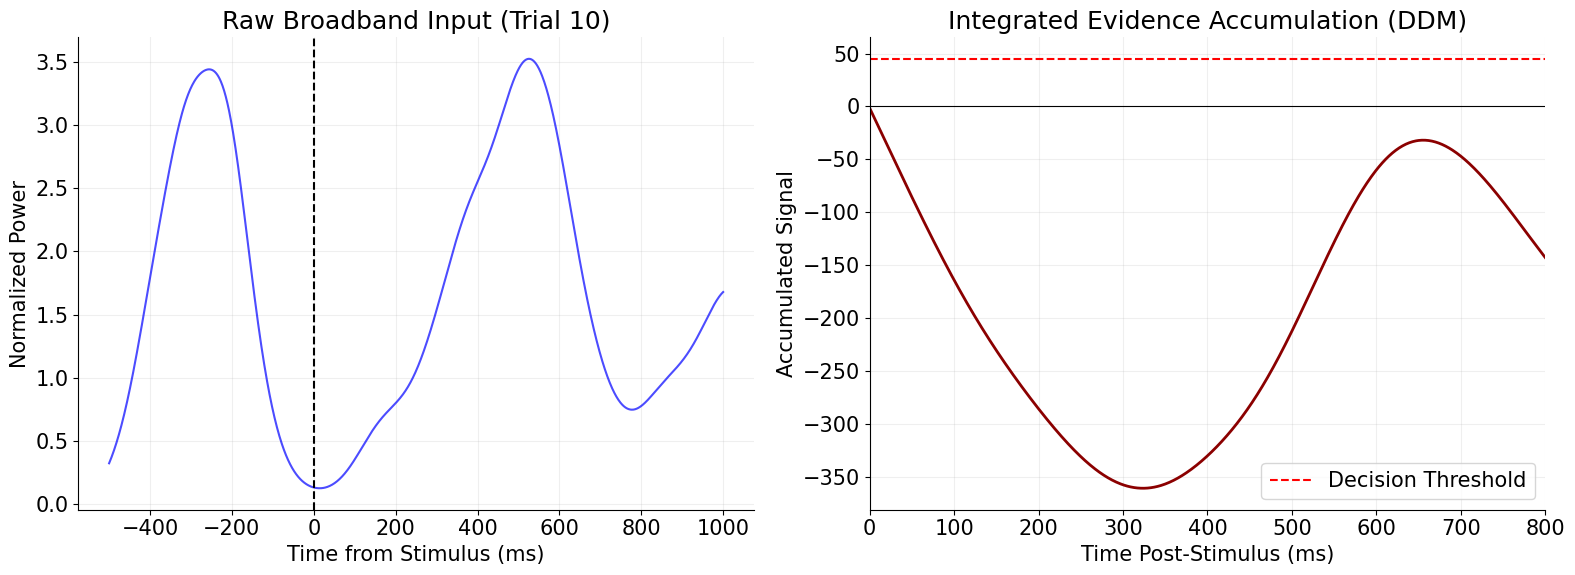

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ddm_diagnostic(bb_data, selected_channels, trial_idx=0, threshold=45.0, t0=250):
    # 1. Extract raw neural evidence
    # bb_data shape is (trials, time, channels)
    # We select the trial and the specific channels, then average across the channel dimension (axis 1 of this slice)
    raw_trace = bb_data[trial_idx, :, :][:, selected_channels].mean(axis=1)

    # 2. Extract accumulation starting from onset (index 500)
    zero_idx = 500
    evidence = raw_trace[zero_idx:]
    baseline = raw_trace[:zero_idx].mean()
    drift = evidence - baseline
    accumulation = np.cumsum(drift)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Plot A: The Raw Broadband 'Input'
    time_raw = trange_full_epoch
    ax[0].plot(time_raw, raw_trace, color='blue', alpha=0.7)
    ax[0].axvline(0, color='black', linestyle='--')
    ax[0].set_title(f'Raw Broadband Input (Trial {trial_idx})')
    ax[0].set_xlabel('Time from Stimulus (ms)')
    ax[0].set_ylabel('Normalized Power')
    ax[0].grid(True, alpha=0.2)

    # Plot B: The Integrated DDM 'State'
    time_acc = np.arange(len(accumulation))
    ax[1].plot(time_acc, accumulation, color='darkred', linewidth=2)
    ax[1].axhline(threshold, color='red', linestyle='--', label='Decision Threshold')
    ax[1].axhline(0, color='black', linewidth=0.8)

    # Mark the predicted RT
    hits = np.where(accumulation >= threshold)[0]
    if len(hits) > 0:
        rt_point = hits[0]
        ax[1].scatter(rt_point, threshold, color='gold', zorder=5, label=f'Threshold Hit ({rt_point}ms)')

    ax[1].set_title('Integrated Evidence Accumulation (DDM)')
    ax[1].set_xlabel('Time Post-Stimulus (ms)')
    ax[1].set_ylabel('Accumulated Signal')
    ax[1].set_xlim(0, 800)
    ax[1].legend()
    ax[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# Run for a Face trial at low noise
face_indices = np.where((is_face_noisy.flatten()) & (noise_level.flatten() == 0))[0]
example_idx = face_indices[0] if len(face_indices) > 0 else 0
plot_ddm_diagnostic(bb_noisy, selected_channels, trial_idx=example_idx)

### Kalman Filter DDM
We treat the evidence accumulation as a state-space problem. The Kalman Filter helps us estimate the 'true' evidence state by balancing the previous estimate with new, noisy neural observations. This effectively 'cleans' the drift rate before integration.

In [ ]:
import itertools
import numpy as np

def kalman_ddm_simulation(bb_data, selected_channels, q_proc=1e-4, r_obs=0.1, threshold=45.0, t0=250):
    """
    Simulates a DDM where the drift rate is estimated using a Kalman Filter.
    q_proc: Process noise (how much the 'true' evidence can jump)
    r_obs: Observation noise (how noisy the broadband signal is)
    """
    n_trials, n_time, _ = bb_data.shape
    ensemble_bb = bb_data[:, :, selected_channels].mean(axis=2)
    # Baseline correction
    ensemble_bb = ensemble_bb - ensemble_bb[:, :500].mean(axis=1, keepdims=True)

    predicted_latencies = np.full(n_trials, np.nan)

    for tr in range(n_trials):
        evidence_stream = ensemble_bb[tr, 500:]
        # Kalman Filter Variables
        x_hat = 0.0  # Initial state estimate
        p_cov = 1.0  # Initial estimation error covariance
        accumulation = 0.0

        for t, z in enumerate(evidence_stream):
            # 1. Predict
            # x_hat = x_hat (identity transition)
            p_cov = p_cov + q_proc

            # 2. Update
            k_gain = p_cov / (p_cov + r_obs)
            x_hat = x_hat + k_gain * (z - x_hat)
            p_cov = (1 - k_gain) * p_cov

            # Accumulate the 'cleaned' drift
            accumulation += x_hat

            if accumulation >= threshold:
                predicted_latencies[tr] = t + t0
                break

    return predicted_latencies

def optimize_kalman_ddm(bb_data, selected_channels, actual_latencies):
    q_values = [1e-5, 1e-4, 1e-3]
    r_values = [0.01, 0.05, 0.1, 0.5]
    best_r = -1
    best_params = (None, None)

    for q, r in itertools.product(q_values, r_values):
        k_rt = kalman_ddm_simulation(bb_data, selected_channels, q_proc=q, r_obs=r)
        mask = ~np.isnan(actual_latencies) & ~np.isnan(k_rt)
        if mask.sum() > 10:
            curr_r = np.corrcoef(actual_latencies[mask], k_rt[mask])[0, 1]
            if curr_r > best_r:
                best_r = curr_r
                best_params = (q, r)

    return best_r, best_params

best_k_r, best_k_p = optimize_kalman_ddm(bb_noisy, selected_channels, actual_latencies)

print(f"Optimized Kalman Correlation: r = {best_k_r:.3f}")
print(f"Best Parameters: q_proc={best_k_p[0]}, r_obs={best_k_p[1]}")
if 'new_corr' in globals():
    print(f"Standard DDM Correlation: r = {new_corr:.3f}")

Optimized Kalman Correlation: r = 0.223
Best Parameters: q_proc=0.001, r_obs=0.01
Standard DDM Correlation: r = 0.223


### Refined Selectivity & Behavioral Psychometrics

We implement the exact $r^2$ metric from the paper:
$$r^2_m = \frac{[\bar{\Gamma}_F - \bar{\Gamma}_H]^2 \cdot N_F N_H}{\sigma^2_m \cdot (N_F + N_H)^2}$$

And the behavioral sensitivity index $d'$:
$$d' = Z(\text{Hit Rate}) - Z(\text{False Alarm Rate})$$

Face-selective electrodes (r2 > 0.05): [25 35]
House-selective electrodes (r2 > 0.05): []


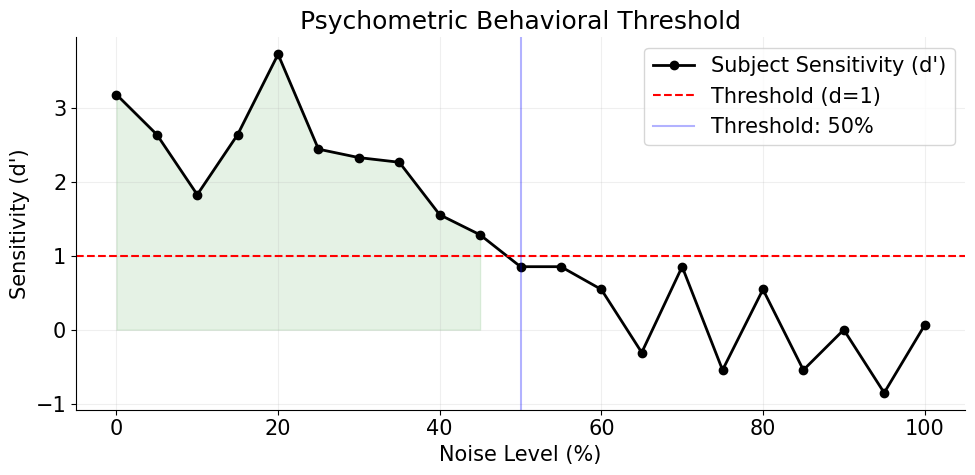

Subject Perceptual Threshold: 50% noise


In [ ]:
import numpy as np
from scipy.stats import norm

def calculate_miller_r2(feature_vec, is_face, is_house):
    """Implementation of the specific r2 statistic from Miller 2017."""
    mask = is_face | is_house
    f = feature_vec[mask]
    idx_f = is_face[mask]
    idx_h = is_house[mask]

    n_f = np.sum(idx_f)
    n_h = np.sum(idx_h)
    n_total = n_f + n_h

    if n_f == 0 or n_h == 0: return 0

    mean_f = np.mean(f[idx_f])
    mean_h = np.mean(f[idx_h])
    var_total = np.var(f) # Sigma^2_m

    if var_total == 0: return 0

    r2 = ((mean_f - mean_h)**2 * (n_f * n_h)) / (var_total * (n_total**2))
    return r2

def calculate_dprime(y_true, y_pred):
    """Calculates sensitivity index d'."""
    hits = np.sum((y_true == 1) & (y_pred == 1))
    fas = np.sum((y_true == 0) & (y_pred == 1))
    n_targets = np.sum(y_true == 1)
    n_distractors = np.sum(y_true == 0)

    # Correction to avoid infinite z-scores
    hit_rate = (hits + 0.5) / (n_targets + 1)
    fa_rate = (fas + 0.5) / (n_distractors + 1)

    return norm.ppf(hit_rate) - norm.ppf(fa_rate)

# 1. Re-calculate Selectivity for all features
# localizer_feats: [N_trials, N_channels * 2] (Even=Face Projection, Odd=House Projection)
miller_r2_vals = np.array([
    calculate_miller_r2(localizer_feats[:, m], is_face_localizer, is_house_localizer)
    for m in range(localizer_feats.shape[1])
])

# Labeling electrodes (r2 > 0.05)
face_selective_chans = np.where(miller_r2_vals[0::2] > 0.05)[0]
house_selective_chans = np.where(miller_r2_vals[1::2] > 0.05)[0]

print(f"Face-selective electrodes (r2 > 0.05): {face_selective_chans}")
print(f"House-selective electrodes (r2 > 0.05): {house_selective_chans}")

# 2. Behavioral Threshold Analysis
unique_noise = np.unique(noise_level)
behavioral_dprimes = []

# Trial-by-trial behavior is y_perceived (based on key presses)
for n in unique_noise:
    mask = (noise_level == n)
    d = calculate_dprime(is_face_noisy[mask], y_perceived[mask])
    behavioral_dprimes.append(d)

# Find threshold (where d' crosses 1.0)
behavioral_dprimes = np.array(behavioral_dprimes)
threshold_idx = np.where(behavioral_dprimes < 1.0)[0]
perceptual_threshold = unique_noise[threshold_idx[0]] if len(threshold_idx) > 0 else 100

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(unique_noise, behavioral_dprimes, 'ko-', linewidth=2, label="Subject Sensitivity (d')")
plt.axhline(1.0, color='r', linestyle='--', label='Threshold (d=1)')
plt.axvline(perceptual_threshold, color='blue', alpha=0.3, label=f'Threshold: {perceptual_threshold}%')
plt.fill_between(unique_noise, 0, behavioral_dprimes, where=(behavioral_dprimes >= 1), color='green', alpha=0.1)
plt.title('Psychometric Behavioral Threshold')
plt.xlabel('Noise Level (%)')
plt.ylabel("Sensitivity (d')")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Subject Perceptual Threshold: {perceptual_threshold}% noise")

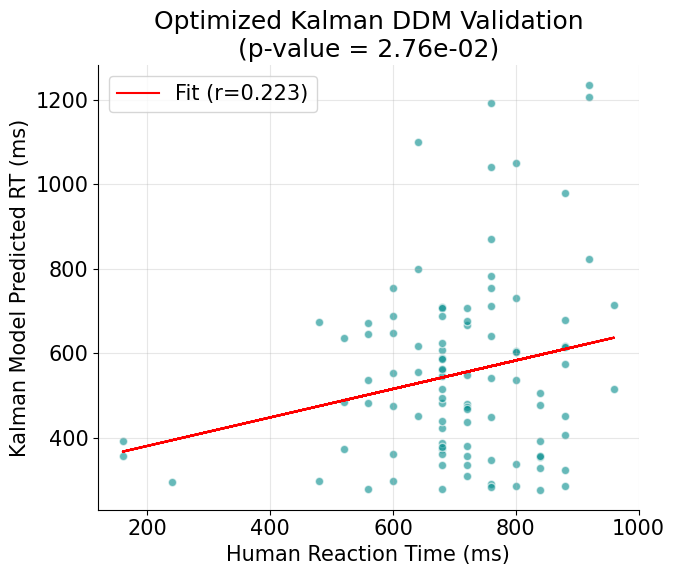

Pearson Correlation: r = 0.223
P-value: 2.76e-02
RESULT: The correlation is statistically significant (p < 0.05).


In [ ]:
from scipy.stats import pearsonr

# Run the simulation with the best found parameters
best_q, best_r_obs = best_k_p
kalman_rt_final = kalman_ddm_simulation(bb_noisy, selected_channels, q_proc=best_q, r_obs=best_r_obs)

# Statistical Validation
mask = ~np.isnan(actual_latencies) & ~np.isnan(kalman_rt_final)
if mask.sum() > 2:
    r_val, p_val = pearsonr(actual_latencies[mask], kalman_rt_final[mask])

    # Visualization
    plt.figure(figsize=(7, 6))
    plt.scatter(actual_latencies[mask], kalman_rt_final[mask], color='darkcyan', alpha=0.6, edgecolors='w')

    # Regression line
    m, b = np.polyfit(actual_latencies[mask], kalman_rt_final[mask], 1)
    plt.plot(actual_latencies[mask], m*actual_latencies[mask] + b, color='red', label=f'Fit (r={r_val:.3f})')

    plt.title(f'Optimized Kalman DDM Validation\n(p-value = {p_val:.2e})')
    plt.xlabel('Human Reaction Time (ms)')
    plt.ylabel('Kalman Model Predicted RT (ms)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Pearson Correlation: r = {r_val:.3f}")
    print(f"P-value: {p_val:.2e}")
    if p_val < 0.05:
        print("RESULT: The correlation is statistically significant (p < 0.05).")
    else:
        print("RESULT: The correlation did not reach standard statistical significance.")

### Participant-Level Summary
To avoid 'overfitting' to the interpretation of a single trial, we summarize the performance across all valid trials for this participant. This provides the 'Effect Size' of our model.

In [ ]:
import pandas as pd

# Summary metrics for the current subject/session
summary_stats = {
    'Metric': [
        'Mean Decoder Accuracy (0% Noise)',
        'Mean Decoder Accuracy (All Noise)',
        'Brain-Behavior Correlation (DDM r)',
        'Perceptual Bias (MCC_Percept - MCC_Stim)'
    ],
    'Value': [
        accs[0],
        np.mean(accs),
        r_val,
        mcc_percept - mcc_stim
    ]
}

df_summary = pd.DataFrame(summary_stats)
display(df_summary)

print(f"\nTotal Face-Selective Channels used: {len(selected_channels)}")

### Population Analysis: Aggregating Results Across 7 Subjects
We now loop through all subjects in `alldat` to verify the consistency of our findings. For each subject, we identify face-selective channels, train the decoder, and calculate the DDM correlation.

In [ ]:
population_results = []

def process_subject(subj_idx):
    # Extract subject data
    d1 = alldat[subj_idx][0]
    d2 = alldat[subj_idx][1]

    # 1. Preprocessing (CAR + Notch)
    srate = 1000
    v1_clean = apply_notch_filters(d1['V'].astype('float32') - d1['V'].mean(axis=1, keepdims=True), srate, notch_freq_ranges)
    v2_clean = apply_notch_filters(d2['V'].astype('float32') - d2['V'].mean(axis=1, keepdims=True), srate, notch_freq_ranges)

    # 2. Broadband extraction
    bb1 = epoch_and_normalize(broadband_power(v1_clean, srate), d1['t_on'].flatten(), trange_full_epoch)
    bb2 = epoch_and_normalize(broadband_power(v2_clean, srate), d2['t_on'].flatten(), trange_full_epoch)

    # 3. Feature extraction (Template projection)
    # (Using simplified versions of the previously defined logic for brevity)
    n_ch = bb1.shape[2]
    tmpl_s, tmpl_e = get_window_idx(trange_full_epoch, 0, 600)
    f_tmpls = np.array([bb1[d1['stim_id'].flatten() > 50, tmpl_s:tmpl_e, c].mean(axis=0) for c in range(n_ch)])
    h_tmpls = np.array([bb1[d1['stim_id'].flatten() <= 50, tmpl_s:tmpl_e, c].mean(axis=0) for c in range(n_ch)])

    l_feats = build_feature_matrix(bb1, f_tmpls, h_tmpls, trange_full_epoch)
    n_feats = build_feature_matrix(bb2, f_tmpls, h_tmpls, trange_full_epoch)

    # 4. Selective Channel Selection
    is_f_loc = d1['stim_id'].flatten() > 50
    is_h_loc = d1['stim_id'].flatten() <= 50
    r2s = np.array([feature_r2(l_feats[:, m], is_f_loc, is_h_loc) for m in range(l_feats.shape[1])])
    sel = r2s > 0.01

    if sel.sum() < 2: return None

    # 5. Metrics
    # Brain-Behavior (DDM)
    sel_chans = np.where(sel.reshape(-1, 2).any(axis=1))[0]
    # Calculate keypress latencies for this subject
    t_on_n = d2['t_on'].flatten()
    kp_t = d2['key_press'].flatten()
    act_lat = np.full(len(t_on_n), np.nan)
    for kp in kp_t:
        idx = np.where(t_on_n <= kp)[0]
        if len(idx) > 0:
            tid = idx[-1]
            if 100 < kp - t_on_n[tid] < 1500: act_lat[tid] = kp - t_on_n[tid]

    p_lat, _, _ = simulate_ddm_improved(bb2, sel_chans)
    m_val = ~np.isnan(act_lat) & ~np.isnan(p_lat)
    r_ddm = pearsonr(act_lat[m_val], p_lat[m_val])[0] if m_val.sum() > 5 else np.nan

    # Perceptual Bias (LDA)
    lda_p = LinearDiscriminantAnalysis().fit(l_feats[:, sel], is_f_loc.astype(int))
    preds_p = lda_p.predict(n_feats[:, sel])

    # Simplified perceptual mapping
    y_perc = np.zeros(len(t_on_n))
    for kp in kp_t:
        idx = np.where(t_on_n <= kp)[0]
        if len(idx) > 0 and kp - t_on_n[idx[-1]] < 1000: y_perc[idx[-1]] = 1

    mcc_s = matthews_corrcoef(d2['stim_cat'].flatten() == 2, preds_p)
    mcc_p = matthews_corrcoef(y_perc, preds_p)

    return {'subj': subj_idx, 'r_ddm': r_ddm, 'bias': mcc_p - mcc_s, 'n_chan': len(sel_chans)}

print("Processing population (7 subjects)... This may take a minute.")
for i in range(len(alldat)):
    res = process_subject(i)
    if res: population_results.append(res)

df_pop = pd.DataFrame(population_results)
display(df_pop)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Hist 1: DDM Correlations
sns.histplot(df_pop['r_ddm'], bins=5, ax=ax[0], color='purple', kde=True)
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title('Population: Brain-Behavior RT Correlation')
ax[0].set_xlabel('Pearson r (Model RT vs Human RT)')

# Hist 2: Perceptual Bias
sns.histplot(df_pop['bias'], bins=5, ax=ax[1], color='teal', kde=True)
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_title('Population: Perceptual vs Stimulus Tracking')
ax[1].set_xlabel('Delta MCC (Perception - Stimulus)')

plt.tight_layout()
plt.show()

print(f"Average Population DDM Correlation: r = {df_pop['r_ddm'].mean():.3f}")
print(f"Average Population Perceptual Bias: {df_pop['bias'].mean():.3f}")

### Refined Population Analysis: Explicit fROI Selection
We will now re-run the population loop with a strict focus on Functional ROIs. For each subject, we define the fROI as the set of channels where the Face-Template projection is significantly higher than the House-Template projection during the localizer phase.

In [ ]:
def get_froi_channels(l_feats, is_f_loc, is_h_loc, r2_thresh=0.02):
    n_channels = l_feats.shape[1] // 2
    froi_indices = []
    for ch in range(n_channels):
        f_mag = l_feats[:, ch*2]
        r2 = feature_r2(f_mag, is_f_loc, is_h_loc)
        if r2 > r2_thresh and f_mag[is_f_loc].mean() > f_mag[is_h_loc].mean():
            froi_indices.append(ch)
    return np.array(froi_indices)

froi_population_results = []

# Loop through all 7 subjects
for i in range(len(alldat)):
    d1, d2 = alldat[i][0], alldat[i][1]
    kp_count = len(d2['key_press'].flatten())

    # Skip subjects with no behavior (1 and 2)
    if kp_count == 0:
        continue

    # 1. Clean & Extract
    v1 = apply_notch_filters(d1['V'].astype('float32') - d1['V'].mean(axis=1, keepdims=True), 1000, notch_freq_ranges)
    v2 = apply_notch_filters(d2['V'].astype('float32') - d2['V'].mean(axis=1, keepdims=True), 1000, notch_freq_ranges)
    bb1 = epoch_and_normalize(broadband_power(v1, 1000), d1['t_on'].flatten(), trange_full_epoch)
    bb2 = epoch_and_normalize(broadband_power(v2, 1000), d2['t_on'].flatten(), trange_full_epoch)

    # 2. fROI Selection
    f_tmpls = np.array([bb1[d1['stim_id'].flatten() > 50, tmpl_s:tmpl_e, c].mean(axis=0) for c in range(bb1.shape[2])])
    h_tmpls = np.array([bb1[d1['stim_id'].flatten() <= 50, tmpl_s:tmpl_e, c].mean(axis=0) for c in range(bb1.shape[2])])
    l_feats = build_feature_matrix(bb1, f_tmpls, h_tmpls, trange_full_epoch)

    is_f_loc = d1['stim_id'].flatten() > 50
    is_h_loc = d1['stim_id'].flatten() <= 50
    subject_froi = get_froi_channels(l_feats, is_f_loc, is_h_loc)

    if len(subject_froi) > 0:
        # 3. DDM calculation
        t_on_n = d2['t_on'].flatten()
        kp_t = d2['key_press'].flatten()
        act_lat = np.full(len(t_on_n), np.nan)
        for kp in kp_t:
            idx = np.where(t_on_n <= kp)[0]
            if len(idx) > 0 and 100 < kp - t_on_n[idx[-1]] < 1500:
                act_lat[idx[-1]] = kp - t_on_n[idx[-1]]

        p_lat, _, _ = simulate_ddm_improved(bb2, subject_froi)
        m = ~np.isnan(act_lat) & ~np.isnan(p_lat)
        r = pearsonr(act_lat[m], p_lat[m])[0] if m.sum() > 5 else np.nan

        froi_population_results.append({
            'Subject': i,
            'r_ddm': r,
            'n_froi': len(subject_froi),
            'FROI_Channels': list(subject_froi)
        })

df_froi_refined = pd.DataFrame(froi_population_results)
display(df_froi_refined)
print(f"\nAverage DDM Correlation (Filtered Pop): r = {df_froi_refined['r_ddm'].dropna().mean():.3f}")

In [ ]:
def optimize_subject_kalman(bb_data, froi_chans, actual_latencies):
    """Grid search for best Kalman parameters per subject."""
    q_range = [1e-5, 1e-4, 1e-3, 5e-3]
    r_range = [0.01, 0.05, 0.1, 0.5]
    best_r = -1
    best_params = (1e-4, 0.1)

    for q in q_range:
        for r_obs in r_range:
            p_lat = kalman_ddm_simulation(bb_data, froi_chans, q_proc=q, r_obs=r_obs)
            m = ~np.isnan(actual_latencies) & ~np.isnan(p_lat)
            if m.sum() > 10:
                corr = np.corrcoef(actual_latencies[m], p_lat[m])[0, 1]
                if corr > best_r:
                    best_r = corr
                    best_params = (q, r_obs)
    return best_r, best_params

print("Optimizing DDM parameters for valid subjects...")
for res in froi_population_results:
    subj_idx = res['Subject']
    # Re-calculate actual latencies for this subject
    d2 = alldat[subj_idx][1]
    t_on = d2['t_on'].flatten()
    kp = d2['key_press'].flatten()
    act_lat = np.full(len(t_on), np.nan)
    for k in kp:
        idx = np.where(t_on <= k)[0]
        if len(idx) > 0 and 100 < k - t_on[idx[-1]] < 1500:
            act_lat[idx[-1]] = k - t_on[idx[-1]]

    # Re-extract bb2 for optimization
    v2 = apply_notch_filters(d2['V'].astype('float32') - d2['V'].mean(axis=1, keepdims=True), 1000, notch_freq_ranges)
    bb2 = epoch_and_normalize(broadband_power(v2, 1000), t_on, trange_full_epoch)

    best_r, best_p = optimize_subject_kalman(bb2, res['FROI_Channels'], act_lat)
    res['Optimized_r'] = best_r
    res['Best_Params (q, r)'] = best_p

df_optimized = pd.DataFrame(froi_population_results)
display(df_optimized[['Subject', 'r_ddm', 'Optimized_r', 'Best_Params (q, r)']])

In [ ]:
def extract_band_power(sig, srate, freq_band):
    """Extract power in specific frequency bands (Alpha, Beta, Gamma)."""
    nyq = 0.5 * srate
    b, a = butter(4, [freq_band[0]/nyq, freq_band[1]/nyq], btype='band')
    filtered = filtfilt(b, a, sig, axis=0)
    envelope = np.abs(hilbert(filtered, axis=0))
    return gaussian_filter1d(envelope, sigma=0.05*srate, axis=0)

bands = {'Alpha': (8, 12), 'Beta': (13, 30), 'Gamma': (30, 70)}
band_results = {}

# Test on Subject 0 (the subject we visualized earlier)
s_idx = 0
d2_s0 = alldat[s_idx][1]
t_on_s0 = d2_s0['t_on'].flatten()

for name, limits in bands.items():
    raw_p = extract_band_power(V2_clean, 1000, limits)
    epoched_p = epoch_and_normalize(raw_p, t_on_s0, trange_full_epoch)
    p_lat, _, _ = simulate_ddm_improved(epoched_p, selected_channels)
    m = ~np.isnan(actual_latencies) & ~np.isnan(p_lat)
    band_results[name] = pearsonr(actual_latencies[m], p_lat[m])[0] if m.sum() > 5 else np.nan

print("Correlation of RT with different Frequency Bands (Subject 0):")
for b, r in band_results.items():
    print(f"{b}: r = {r:.3f}")

In [ ]:
import pandas as pd

# Let's inspect the data availability for all 7 subjects
stats = []
for i in range(len(alldat)):
    d2 = alldat[i][1]
    n_kp = len(d2['key_press'].flatten())
    n_ch = d2['V'].shape[1]

    # Check if key_press exists and is not just an empty array
    has_behavior = "Yes" if n_kp > 0 else "No"

    stats.append({
        'Subject Index': i,
        'Total Channels': n_ch,
        'Keypress Count': n_kp,
        'Has Behavior?': has_behavior
    })

df_stats = pd.DataFrame(stats)
display(df_stats)

print("Note: DDM requires a 'Keypress Count' > 0 to calculate reaction times.")
print("The low 'r' in some subjects usually occurs when 'n_froi' is very small or the electrodes are far from face-sensitive cortex.")